# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 25 - 3er bimestre 2026

## **Alumno 1:** Franco Marcelo Morero

Este primer TP comienza la semana de la clase 2 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 17 de julio (hora de Argentina)**.

La resolución del TP debe realizarse en **parejas**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que ambos deben trabajar conjuntamente en la resolución de cada pregunta. De esta manera, se promueve el debate, la discusión y la construcción de una conclusión compartida sobre cómo abordar y resolver cada pregunta. También está permitido realizar el trabajo de forma **individual** si así lo desean, aunque esta modalidad no es la más recomendable.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP1 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo en formato `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/xC3HzHwVqt35M23c7)**. Tanto los resultados, tablas, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el mismo notebook.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL ÚNICO MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP1.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERNOMBREALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERNOMBREALUMNO2-TP1-Co25.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP1-Co25.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros a optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-1, fin=1`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado). Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger. Pero tampoco vale usar una `tanh` sola, usen otra función, o si la van a usar debe estar combinada con otros patrones no lineales. Ya que al ser la función de activación tambien una `tanh`, el modelo la tendrá muy fácil converger a ella.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para cada uno de los 3 learning rates. Las 3 gráficas deben estar en el mismo plot y superpuestas para que la comparación visual sea más fácil. Deben graficarlas con diferente color y con leyenda para no confundirlas.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

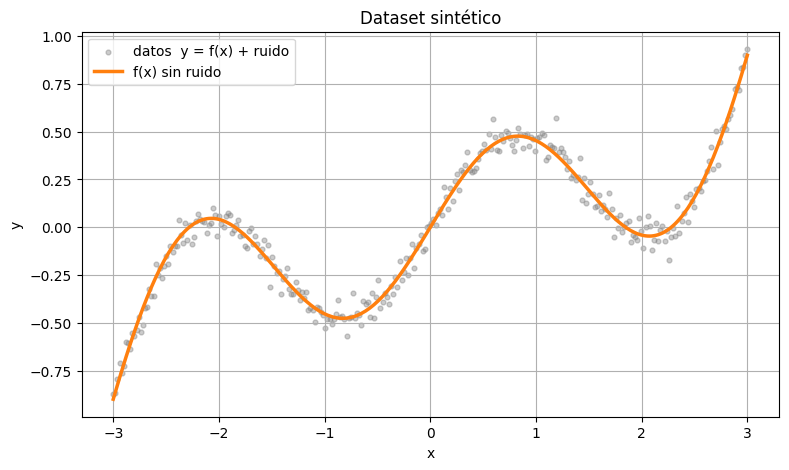

In [2]:
n = 300
x = np.linspace(-3, 3, n)

# f(x) = 0.6·sen(2x) + 0.05·x³, 
# reescalada a [-0.9, 0.9] para que caiga dentro del rango de tanh (-1,1)
funcion_no_lineal = 0.6 * np.sin(2 * x) + 0.05 * x**3
funcion_no_lineal = funcion_no_lineal * (0.9 / np.max(np.abs(funcion_no_lineal)))
ruido = np.random.normal(0, 0.05, size=n)
y = funcion_no_lineal + ruido

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=12, alpha=0.4, color="gray", label="datos  y = f(x) + ruido")
plt.plot(x, funcion_no_lineal, color="tab:orange", lw=2.5, label="f(x) sin ruido")
plt.title("Dataset sintético")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
def modelo(w, b, X):
    """
        z = w*x + b;
        ŷ = tanh(z);
    """
    return np.tanh(w * X + b)


def J_mse(w, b, X, Y):
    """
        J(w,b) = MSE
    """
    e = Y - modelo(w, b, X)
    return np.mean(e**2)


def grad(w, b, X, Y):
    """
        Con e=Y-ŷ y regla de la cadena (dŷ/dz = 1 - tanh²(z) = 1 - ŷ²):
        dJ/dw = -(2/m)·Σ e·(1-ŷ²)·x
        dJ/db = -(2/m)·Σ e·(1-ŷ²)
    """
    yhat = modelo(w, b, X)
    e = Y - yhat
    g = 1 - yhat**2
    m = len(X)
    dw = -(2 / m) * np.sum(e * g * X)
    db = -(2 / m) * np.sum(e * g)
    return dw, db

In [4]:
# Guardo para usar también en Adam
w0, b0 = np.random.randn(), np.random.randn()
print(f"Inicialización -> w0 = {w0:.4f}, b0 = {b0:.4f}")

epocas = 100
learning_rates = (0.1, 0.01, 0.001)

Inicialización -> w0 = -0.8290, b0 = -0.5602


In [5]:
def entrenar_gd(w0, b0, lr, epocas=100):
    w, b = w0, b0
    path_w, path_b, path_J = [w], [b], [J_mse(w, b, x, y)]
    for _ in range(epocas - 1):
        dw, db = grad(w, b, x, y)
        w = w - lr * dw
        b = b - lr * db
        path_w.append(w)
        path_b.append(b)
        path_J.append(J_mse(w, b, x, y))
    return np.array(path_w), np.array(path_b), np.array(path_J)

In [6]:
gd_results = {}
for lr in learning_rates:
    pw, pb, pJ = entrenar_gd(w0, b0, lr, epocas)
    gd_results[lr] = {"path_w": pw, "path_b": pb, "path_J": pJ}
    print(f"GD lr={lr:<6} -> J final = {pJ[-1]:.6f}   (w={pw[-1]:.3f}, b={pb[-1]:.3f})")

GD lr=0.1    -> J final = 0.067908   (w=0.137, b=-0.000)
GD lr=0.01   -> J final = 0.252247   (w=0.005, b=-0.386)
GD lr=0.001  -> J final = 1.029453   (w=-0.765, b=-0.570)


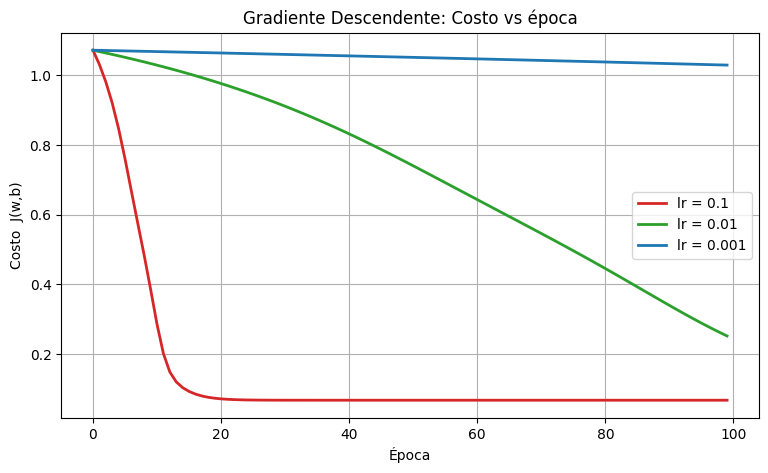

In [7]:
colores = {0.1: "tab:red", 0.01: "tab:green", 0.001: "tab:blue"}

plt.figure(figsize=(9, 5))
for lr in learning_rates:
    plt.plot(range(epocas), gd_results[lr]["path_J"],
             color=colores[lr], lw=2, label=f"lr = {lr}")
plt.title("Gradiente Descendente: Costo vs época")
plt.xlabel("Época")
plt.ylabel("Costo  J(w,b)")
plt.legend()
plt.grid(True)
plt.show()


### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno sin mini-batch (full-batch) y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [8]:
beta1, beta2 = 0.9, 0.999
eps = 1e-8

In [9]:
def entrenar_adam_full(w0, b0, lr, epocas=100):
    w, b = w0, b0
    m_w = m_b = 0.0
    v_w = v_b = 0.0

    path_w, path_b, path_J = [w], [b], [J_mse(w, b, x, y)]

    # t es epoca y pasos
    for t in range(1, epocas):
        # gradiente
        dw, db = grad(w, b, x, y)
        # actualización de momentos
        m_w = beta1 * m_w + (1 - beta1) * dw
        m_b = beta1 * m_b + (1 - beta1) * db
        v_w = beta2 * v_w + (1 - beta2) * dw**2
        v_b = beta2 * v_b + (1 - beta2) * db**2
        # corrección de sesgo
        m_w_hat = m_w / (1 - beta1**t)
        m_b_hat = m_b / (1 - beta1**t)
        v_w_hat = v_w / (1 - beta2**t)
        v_b_hat = v_b / (1 - beta2**t)
        # actualización
        w = w - lr * m_w_hat / (np.sqrt(v_w_hat) + eps)
        b = b - lr * m_b_hat / (np.sqrt(v_b_hat) + eps)

        # guardo por época
        path_w.append(w)
        path_b.append(b)

        # calculo del costo
        path_J.append(J_mse(w, b, x, y))

    return np.array(path_w), np.array(path_b), np.array(path_J)

In [10]:
def entrenar_adam_mini(w0, b0, lr, epocas=100, batch=32):
    w, b = w0, b0
    m_w = m_b = 0.0
    v_w = v_b = 0.0
    t = 0

    path_w, path_b, path_J = [w], [b], [J_mse(w, b, x, y)]

    # t ahora no coincide con la epoca, avanza con el mini batch
    for _ in range(epocas - 1):
        # tomo batchs al azar para no sesgar el entrenamiento
        idx = np.random.permutation(len(x))
        for i in range(0, len(x), batch):
            # batch de datos
            xb = x[idx[i:i + batch]]
            yb = y[idx[i:i + batch]]
            t += 1
            # gradiente
            dw, db = grad(w, b, xb, yb)
            # actualización de momentos
            m_w = beta1 * m_w + (1 - beta1) * dw
            m_b = beta1 * m_b + (1 - beta1) * db
            v_w = beta2 * v_w + (1 - beta2) * dw**2
            v_b = beta2 * v_b + (1 - beta2) * db**2
            # corrección de sesgo
            m_w_hat = m_w / (1 - beta1**t)
            m_b_hat = m_b / (1 - beta1**t)
            v_w_hat = v_w / (1 - beta2**t)
            v_b_hat = v_b / (1 - beta2**t)
            # actualización
            w = w - lr * m_w_hat / (np.sqrt(v_w_hat) + eps)
            b = b - lr * m_b_hat / (np.sqrt(v_b_hat) + eps)

        # guardo por época
        path_w.append(w)
        path_b.append(b)

        # calculo del costo
        path_J.append(J_mse(w, b, x, y))

    return np.array(path_w), np.array(path_b), np.array(path_J)


In [11]:
adam_fb = {}
for lr in learning_rates:
    pw, pb, pJ = entrenar_adam_full(w0, b0, lr, epocas)
    adam_fb[lr] = {"path_w": pw, "path_b": pb, "path_J": pJ}
    print(f"Adam full-batch lr={lr:<6} -> J final = {pJ[-1]:.6f}")

Adam full-batch lr=0.1    -> J final = 0.067950
Adam full-batch lr=0.01   -> J final = 0.068578
Adam full-batch lr=0.001  -> J final = 0.995059


In [12]:
batch_size = 32

adam_mb = {}
for lr in learning_rates:
    pw, pb, pJ = entrenar_adam_mini(w0, b0, lr, epocas, batch=batch_size)
    adam_mb[lr] = {"path_w": pw, "path_b": pb, "path_J": pJ}
    print(f"Adam mini-batch lr={lr:<6} -> J final = {pJ[-1]:.6f}")

Adam mini-batch lr=0.1    -> J final = 0.069027
Adam mini-batch lr=0.01   -> J final = 0.067912
Adam mini-batch lr=0.001  -> J final = 0.070726


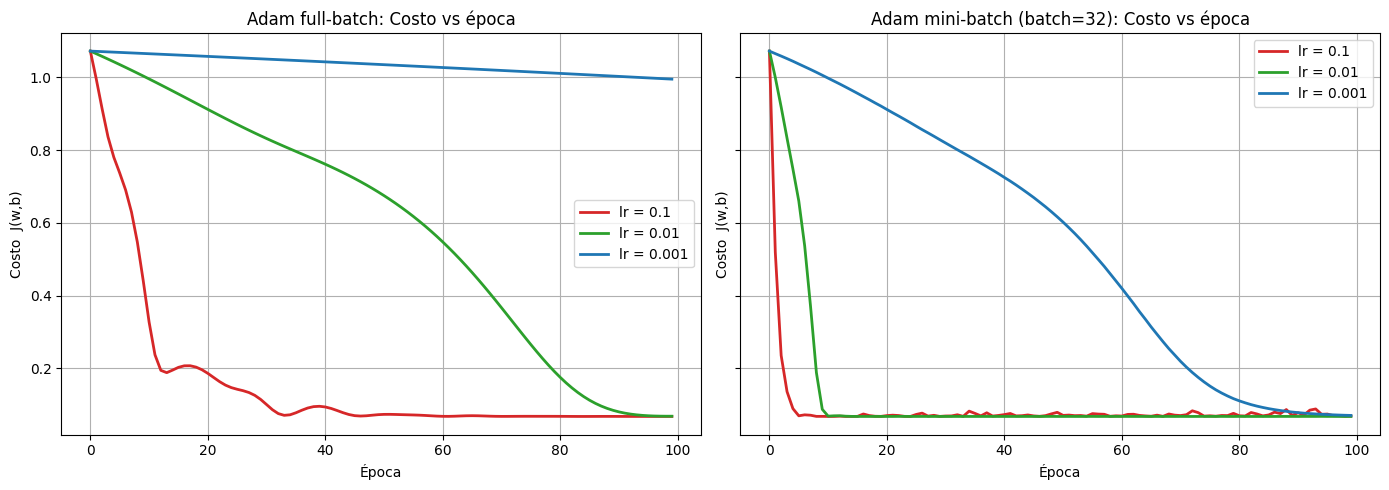

In [13]:
fig, (ax_fb, ax_mb) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for lr in learning_rates:
    ax_fb.plot(range(epocas), adam_fb[lr]["path_J"], color=colores[lr], lw=2, label=f"lr = {lr}")
    ax_mb.plot(range(epocas), adam_mb[lr]["path_J"], color=colores[lr], lw=2, label=f"lr = {lr}")

ax_fb.set_title("Adam full-batch: Costo vs época")
ax_mb.set_title(f"Adam mini-batch (batch={batch_size}): Costo vs época")
for ax in (ax_fb, ax_mb):
    ax.set_xlabel("Época")
    ax.set_ylabel("Costo  J(w,b)")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()


### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate. Y las leyendas deben diferenciar al optimizador por color.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes. Le voy a tomar mucha importancia a este último punto, así que su análisis debe ser claro, detallado y con criterio acorde a los resultados obtenidos.

In [14]:
optimizadores = {
    "GD":            (gd_results, "tab:red"),
    "Adam full":     (adam_fb,    "tab:green"),
    "Adam mini":     (adam_mb,    "tab:blue"),
}

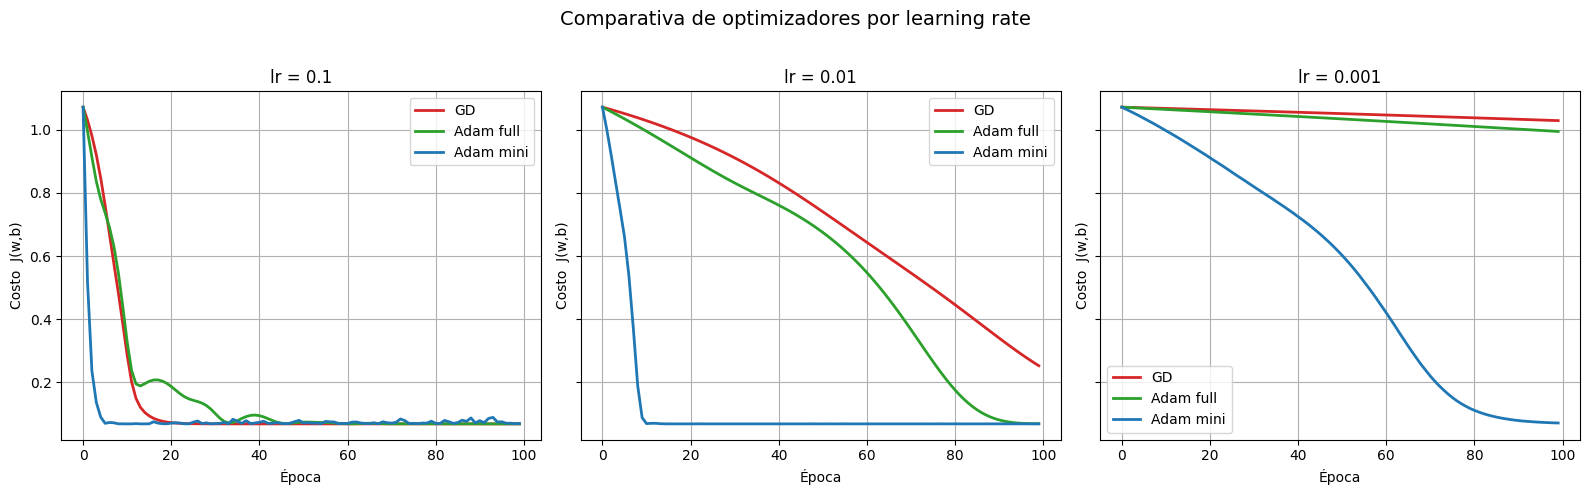

In [15]:
# Rendimiento optimizadores con distintos learning rates
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, lr in zip(axes, learning_rates):
    for nombre, (res, color) in optimizadores.items():
        ax.plot(range(epocas), res[lr]["path_J"], color=color, lw=2, label=nombre)
    ax.set_title(f"lr = {lr}")
    ax.set_xlabel("Época")
    ax.set_ylabel("Costo  J(w,b)")
    ax.legend()
    ax.grid(True)
fig.suptitle("Comparativa de optimizadores por learning rate", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [16]:
# Tabla resumen por optimizador y learning rate:
#   - J_final            : costo al terminar las 100 épocas
#   - epoca_convergencia : época en la que ya quedó a menos de 1% de su costo final (qué tan rápido converge)
#   - J_convergencia     : costo en esa época de convergencia
#   - epoca_min          : época en la que tocó su menor costo
#   - J_min              : menor costo alcanzado
def epoca_convergencia(path_J, tol=0.01):
    objetivo = path_J[-1] * (1 + tol)
    for i, j in enumerate(path_J):
        if j <= objetivo:
            return i
    return len(path_J) - 1

filas = []
for lr in learning_rates:
    for nombre, (res, _) in optimizadores.items():
        pJ = res[lr]["path_J"]
        ec = epoca_convergencia(pJ)
        filas.append({
            "learning_rate": lr,
            "optimizador": nombre,
            "J_final": round(float(pJ[-1]), 6),
            "epoca_convergencia": ec,
            "J_convergencia": round(float(pJ[ec]), 6),
            "epoca_min": int(np.argmin(pJ)),
            "J_min": round(float(np.min(pJ)), 6),
        })
tabla = pd.DataFrame(filas)
print(tabla.to_string(index=False))

 learning_rate optimizador  J_final  epoca_convergencia  J_convergencia  epoca_min    J_min
         0.100          GD 0.067908                  25        0.068453         99 0.067908
         0.100   Adam full 0.067950                  60        0.068271         84 0.067920
         0.100   Adam mini 0.069027                   5        0.069696         10 0.067926
         0.010          GD 0.252247                  99        0.252247         99 0.252247
         0.010   Adam full 0.068578                  96        0.069133         99 0.068578
         0.010   Adam mini 0.067912                  14        0.068077         33 0.067908
         0.001          GD 1.029453                  77        1.039681         99 1.029453
         0.001   Adam full 0.995059                  88        1.004231         99 0.995059
         0.001   Adam mini 0.070726                  98        0.071181         99 0.070726


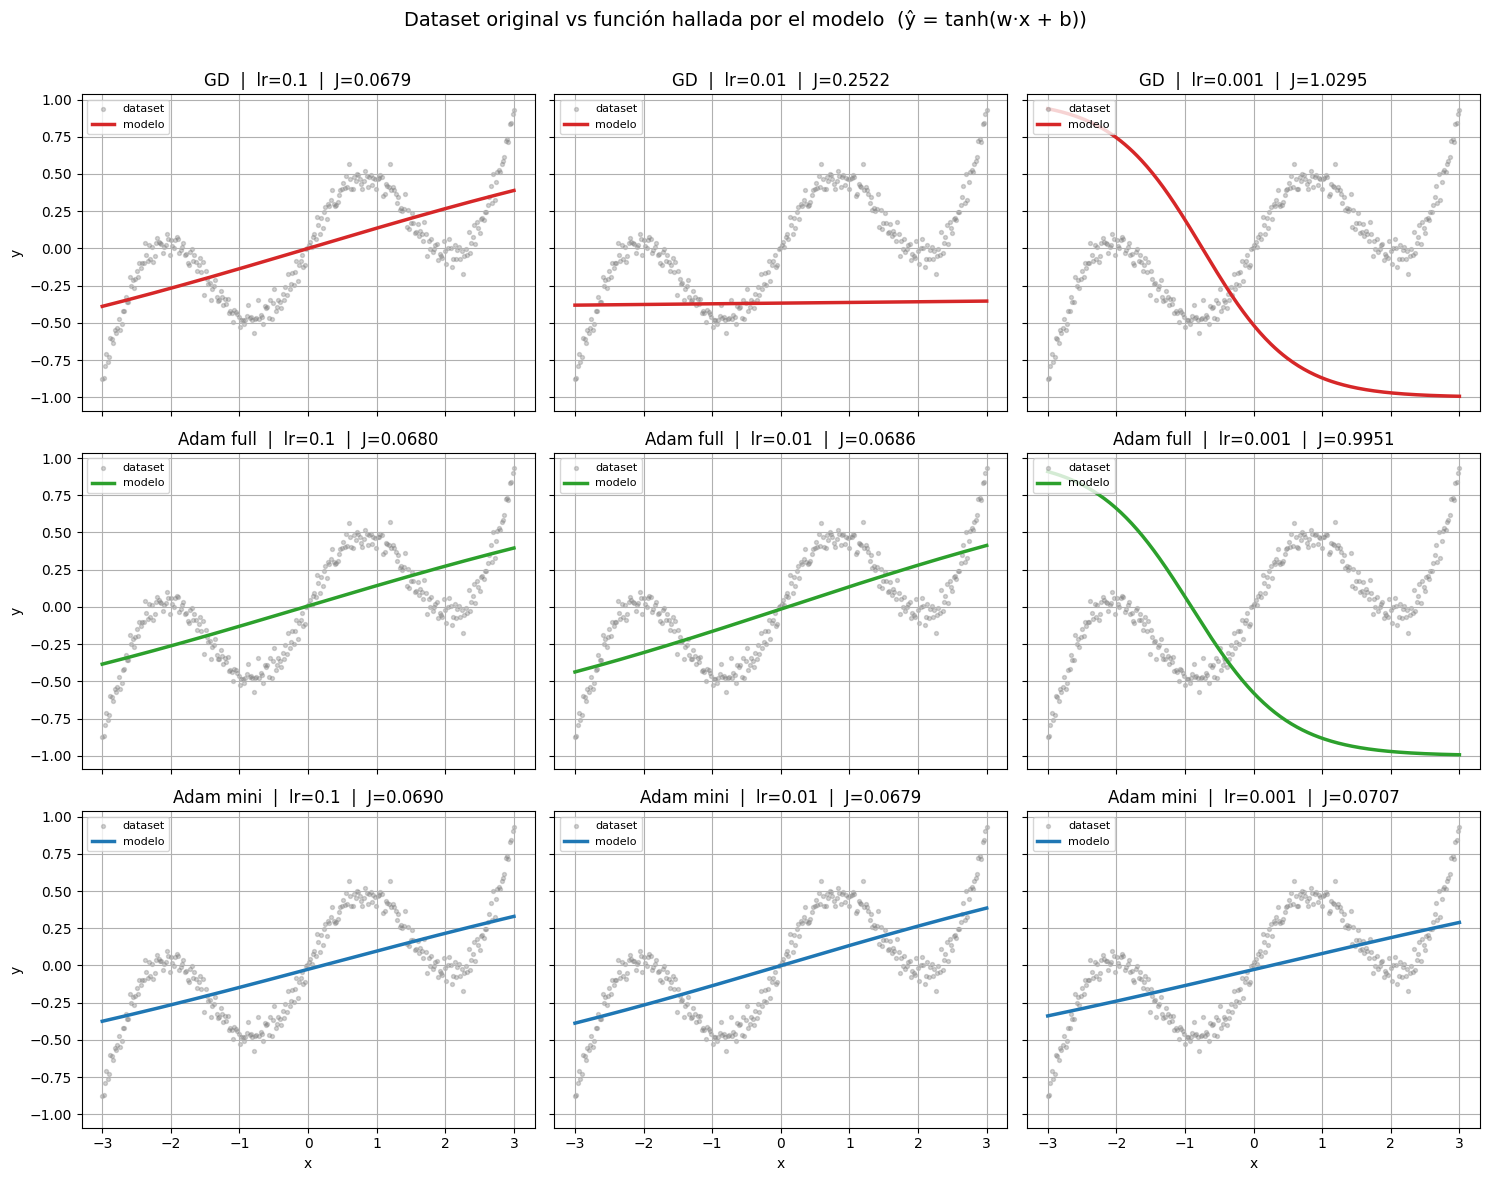

In [17]:
# Dataset original vs curva hallada por el modelo
orden_x = np.argsort(x)
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
for i, (nombre, (res, color)) in enumerate(optimizadores.items()):
    for j, lr in enumerate(learning_rates):
        ax = axes[i, j]
        w_f = res[lr]["path_w"][-1]
        b_f = res[lr]["path_b"][-1]
        yhat = modelo(w_f, b_f, x)
        ax.scatter(x, y, s=8, alpha=0.35, color="gray", label="dataset")
        ax.plot(x[orden_x], yhat[orden_x], color=color, lw=2.5, label="modelo")
        ax.set_title(f"{nombre}  |  lr={lr}  |  J={res[lr]['path_J'][-1]:.4f}")
        ax.grid(True)
        if i == 2:
            ax.set_xlabel("x")
        if j == 0:
            ax.set_ylabel("y")
        ax.legend(loc="upper left", fontsize=8)
fig.suptitle("Dataset original vs función hallada por el modelo  (ŷ = tanh(w·x + b))", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [18]:
# Parámetros finales (w, b) de cada modelo.
filas_wb = []
for lr in learning_rates:
    for nombre, (res, _) in optimizadores.items():
        filas_wb.append({
            "learning_rate": lr,
            "optimizador": nombre,
            "w_final": round(float(res[lr]["path_w"][-1]), 4),
            "b_final": round(float(res[lr]["path_b"][-1]), 4),
        })
tabla_wb = pd.DataFrame(filas_wb)
print(tabla_wb.to_string(index=False))

 learning_rate optimizador  w_final  b_final
         0.100          GD   0.1370  -0.0002
         0.100   Adam full   0.1373   0.0067
         0.100   Adam mini   0.1228  -0.0258
         0.010          GD   0.0053  -0.3858
         0.010   Adam full   0.1513  -0.0144
         0.010   Adam mini   0.1359  -0.0012
         0.001          GD  -0.7648  -0.5698
         0.001   Adam full  -0.7276  -0.6588
         0.001   Adam mini   0.1084  -0.0277


**Conclusiones**

Todos los que convergen quedan cerca del mismo costo `J ≈ 0.068`. Esto pasa porque una sola conexión `tanh(w·x + b)` no puede seguir datos que suben y bajan como el seno con la cúbica. Además veo que los que están cerca del óptimo quedan con un `w` chico, y con `w` chico la tanh está en su parte casi lineal, así que la curva que dibuja se ve como una recta plana que pasa por el medio de los puntos. 

* GD: es el que más cambia dependiendo el lr. Con 0.1 llega al óptimo en la época 25, con 0.01 no le alcanzan las épocas de entrenamiento para llegar al óptimo y con 0.001 no ajusta prácticamente nada. 
* Adam full-batch: anda bien con 0.1 y 0.01 en 100 épocas, pero no ajusta con 0.001. Con 0.1 es más lento que GD para llegar al óptimo, porque llega en la época 60, pero con 0.01 llega antes.
* Adam mini-batch: ajusta bien con los tres valores, incluso con 0.001, que GD y Adam no pudieron. Además se observa en las gráficas de época vs costo que llega más rápido que los demás al óptimo, lo cual se explica en que hace más pasos en la misma época que los demás.


### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico. También si desean pueden hacer que el gráfico sea animado usando `matplotlib.animation` y `IPython.display`.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia. La comparación debe ser clara y detallada.

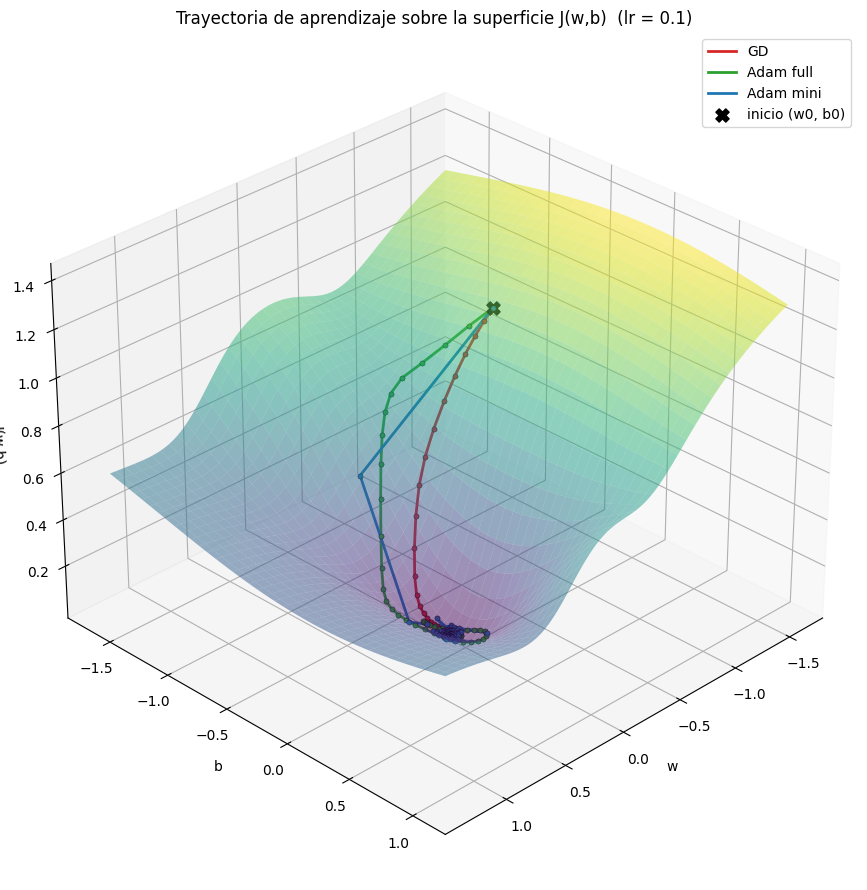

In [19]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Uso lr=0.1 porque los 3 convergen y se ve bien la trayectoria de cada optimizador
lr_3d = 0.1 

# Centro la grilla de modo que contenga tanto el punto inicial como los finales.
w_todos = np.concatenate([res[lr_3d]["path_w"] for res, _ in optimizadores.values()] + [[w0]])
b_todos = np.concatenate([res[lr_3d]["path_b"] for res, _ in optimizadores.values()] + [[b0]])
margen_w = 0.5 + 0.2 * (w_todos.max() - w_todos.min())
margen_b = 0.5 + 0.2 * (b_todos.max() - b_todos.min())

W = np.linspace(w_todos.min() - margen_w, w_todos.max() + margen_w, 120)
B = np.linspace(b_todos.min() - margen_b, b_todos.max() + margen_b, 120)
WW, BB = np.meshgrid(W, B)
JJ = np.zeros_like(WW)
for i in range(WW.shape[0]):
    for j in range(WW.shape[1]):
        JJ[i, j] = J_mse(WW[i, j], BB[i, j], x, y)

# Gráfico 3D: superficie + las 3 trayectorias, todas arrancando en (w0, b0)
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(WW, BB, JJ, alpha=0.5, cmap="viridis", linewidth=0, antialiased=True)

for nombre, (res, color) in optimizadores.items():
    pw, pb, pJ = res[lr_3d]["path_w"], res[lr_3d]["path_b"], res[lr_3d]["path_J"]
    ax.plot(pw, pb, pJ, color=color, lw=2.0, label=nombre)
    # un punto por época, del mismo color que la línea, para ver dónde va cayendo
    ax.scatter(pw, pb, pJ, color=color, s=14, edgecolors="black", linewidths=0.3, depthshade=False)

# marco el punto de partida común
ax.scatter([w0], [b0], [J_mse(w0, b0, x, y)], s=90, c="black", marker="X", label="inicio (w0, b0)")

ax.set_title(f"Trayectoria de aprendizaje sobre la superficie J(w,b)  (lr = {lr_3d})")
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w,b)")
ax.view_init(elev=30, azim=45)
ax.legend()
plt.tight_layout()
plt.show()


**Conclusiones**

La superficie tiene una meseta alta arriba (lo amarillo) y un valle abajo (lo azul-violeta), que es donde está el mínimo. Los tres salen del mismo punto `(w0, b0)`, que es la X negra marcada en la gráfica, y los tres terminan en el fondo del valle, siguiendo una trayectoria distinta.

* GD: es el que baja más derecho. Va siguiendo la pendiente casi en línea recta con pasos de casi el mismo tamaño y sobre el final los pasos se hacen cortos, porque cerca del fondo el gradiente se hace chico. 
* Adam full-batch: en vez de bajar derecho se abre para la izquierda, hace una panza grande y recién ahí cae al valle. Esa panza es el momentum, que al principio lo empuja de más y después lo tiene que corregir. Al final los pasos se hacen más chicos y da "una vuelta" en el valle hasta que llega al óptimo. La vuelta que veo se condice con el aumento de la función de costo con respecto a GD en la época 20 en la gráfica de época vs costo para lr 0.1.
* Adam mini-batch: hace el camino con un codo bien marcado, primero se corre para el costado y después baja casi de una al fondo en dos épocas. Como toca los parámetros una vez por cada lote de 32, mete un montón de pasos por época y por eso llega rapidísimo. En el fondo se ve la manchita azul amontonada, que es el modelo dando vueltas alrededor del mínimo en lugar de frenar justo ahí.


### **RECOMENDACIÓN**:

Voy a valorar mucho que sus análisis, explicaciones y conclusiones sean bastante detalladas y con coherencia en los resultados obtenidos. Donde se evidencie un análisis propio de un humano estudiante de posgrado y no solo copiar y pegar lo que te dijo ChatGPT. Llevo ya años con esto, así que me daré cuenta rapidamente cuando sea así y cuando no.

Les recomiendo revisar el notebook sobre optimizadores que se encuentra en el repo. Pueden acceder mediante el siguiente [enlace](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/blob/ap_2026/CLASE%202/Notebooks/clase2_4_optimizadores.ipynb). En ese notebook vemos cómo aplicar GD y Adam full-batch para una red con relación lineal. Les servirá mucho como guía para realizar esta pregunta. Ahí también podrán ver cómo se hace una animación de un gráfico 3D.

Además, de igual forma tienen disponible el siguiente [material adicional del repo](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/tree/ap_2026/CLASE%202/Teoria/Material%20adicional), el cual le servirá para aplicar Adam, ya no solo en su versión full-batch, sino también en mini-batch

# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

**Descarga del dataset:**  
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- **User_ID:** Código identificador único del cliente que efectuó la compra.  
- **Product_ID:** Código identificador único del producto adquirido.  
- **Age:** Rango de edad del cliente.  
- **Gender:** Género del cliente (F: Femenino, M: Masculino).  
- **Marital_Status:** Estado civil del cliente (0: Soltero, 1: Casado).  
- **City_Category:** Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- **Stay_In_Current_City_Years:** Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- **Product_Category:** Categoría del producto comprado.  
- **Product_Subcategory_1:** Subcategoría principal del producto.  
- **Product_Subcategory_2:** Subcategoría secundaria del producto.  
- **Purchase:** Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra. Tener en cuenta que se busca que el modelo prediga el gasto promedio por cliente, no el gasto en cada nueva transacción individual. Y la idea sería que una vez que el modelo ya esté listo y entrenado, se use para estimar apartir de datos de clientes relativamente nuevos, que solo llevan entre 3 a 5 visitas y compras en la tienda.


### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage, ocurre mucho cuando se usan proporciones como nuevas columnas**.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

In [21]:
# El dataset viene de una tienda: cada fila es una transacción de un cliente.
df = pd.read_csv("dataset_compras.csv")
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (182721, 11)


,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     182721 non-null  int64  
 1   Product_ID                  182721 non-null  object 
 2   Age                         182721 non-null  object 
 3   Gender                      182721 non-null  object 
 4   Marital_Status              182721 non-null  int64  
 5   City_Category               182721 non-null  object 
 6   Stay_In_Current_City_Years  182721 non-null  object 
 7   Product_Category            182721 non-null  int64  
 8   Product_Subcategory_1       140903 non-null  float64
 9   Product_Subcategory_2       77461 non-null   float64
 10  Purchase                    182721 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 15.3+ MB


In [23]:
df.nunique()

User_ID                       7432
Product_ID                    2455
Age                              7
Gender                           2
Marital_Status                   2
City_Category                    3
Stay_In_Current_City_Years       5
Product_Category                20
Product_Subcategory_1           33
Product_Subcategory_2           16
Purchase                      1833
dtype: int64

In [24]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,182721.0,NaN,NaN,NaN,1050060.346796,28840.399617,1000035.0,1024971.0,1050146.0,1074883.0,1099995.0
Product_ID,182721,2455,P00047292,220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,182721,7,46-50,38173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,182721,2,M,98647,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,182721.0,NaN,NaN,NaN,0.647567,0.477729,0.0,0.0,1.0,1.0,1.0
City_Category,182721,3,A,76169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stay_In_Current_City_Years,182721,5,1,41481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,182721.0,NaN,NaN,NaN,10.629123,5.659703,1.0,5.0,11.0,16.0,20.0
Product_Subcategory_1,140903.0,NaN,NaN,NaN,24.557724,12.550279,3.0,13.0,24.0,36.0,45.0
Product_Subcategory_2,77461.0,NaN,NaN,NaN,12.843483,4.593955,5.0,9.0,13.0,17.0,20.0


El dataset tiene 182.721 transacciones y 11 columnas, que se agrupan en tres tipos:

- Identificadores: `User_ID` (7.432 clientes) y `Product_ID` (2.455 productos).
- Atributos del cliente: `Age`, `Gender`, `Marital_Status`, `City_Category` y `Stay_In_Current_City_Years`.
- Atributos del producto y de la compra: `Product_Category`, `Product_Subcategory_1`, `Product_Subcategory_2` y `Purchase`.

`Purchase` es el único monto y es la base para armar el target. 

Varias categóricas vienen como texto (`Age` en rangos, `Stay_In_Current_City_Years` con el `5+`) que hay que procesar.

## Análisis de nulos

In [25]:
# Conteo y porcentaje de valores nulos por columna
nulos = df.isna().sum()
tabla_nulos = pd.DataFrame({
    "nulos": nulos,
    "pct": (nulos / len(df) * 100).round(2),
}).sort_values("pct", ascending=False)
print(tabla_nulos)

                             nulos    pct
Product_Subcategory_2       105260  57.61
Product_Subcategory_1        41818  22.89
User_ID                          0   0.00
Product_ID                       0   0.00
Age                              0   0.00
Gender                           0   0.00
Marital_Status                   0   0.00
City_Category                    0   0.00
Stay_In_Current_City_Years       0   0.00
Product_Category                 0   0.00
Purchase                         0   0.00


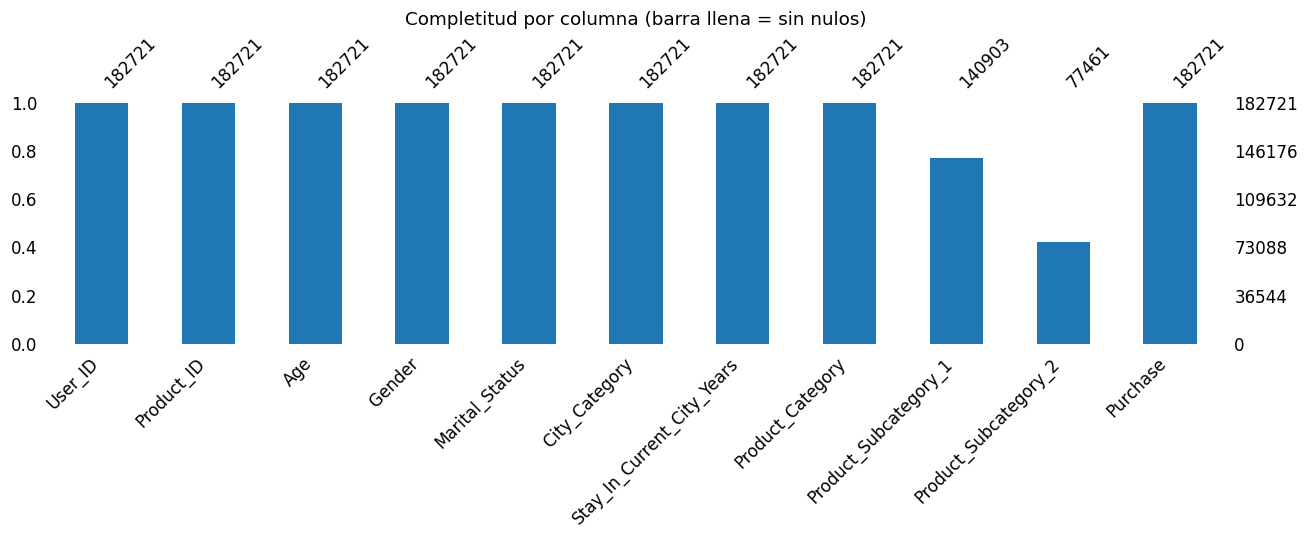

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))
msno.bar(df, ax=ax, fontsize=11, color="tab:blue")
ax.set_title("Completitud por columna (barra llena = sin nulos)")
plt.tight_layout()
plt.show()

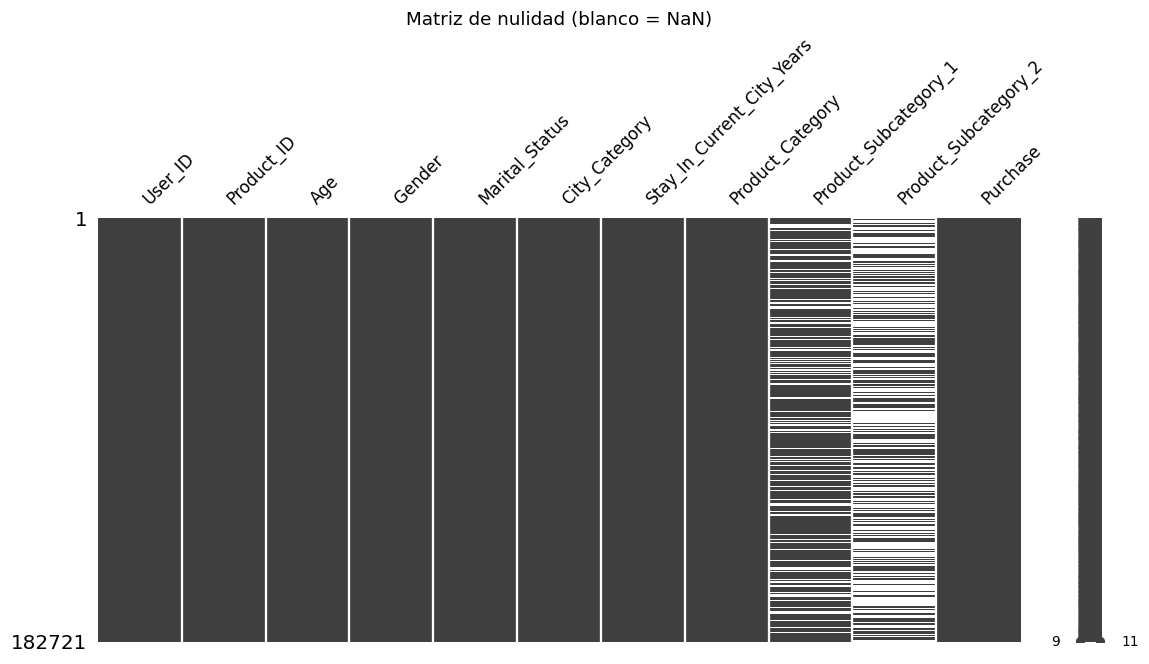

In [27]:
msno.matrix(df, figsize=(12, 5), fontsize=11)
plt.title("Matriz de nulidad (blanco = NaN)")
plt.show()

Veamos a qué productos les faltan más las subcategorías

In [28]:
# Agrupo por producto y mido el % de nulos en cada subcategoría.
faltantes_prod = df.groupby("Product_ID").agg(
    transacciones=("Purchase", "size"),
    sub1_na_pct=("Product_Subcategory_1", lambda s: round(s.isna().mean() * 100, 1)),
    sub2_na_pct=("Product_Subcategory_2", lambda s: round(s.isna().mean() * 100, 1)),
)

# ¿El faltante es todo-o-nada por producto, o hay productos a medias?
parcial_sub1 = ((faltantes_prod["sub1_na_pct"] > 0) & (faltantes_prod["sub1_na_pct"] < 100)).sum()
parcial_sub2 = ((faltantes_prod["sub2_na_pct"] > 0) & (faltantes_prod["sub2_na_pct"] < 100)).sum()
print(f"Productos totales: {len(faltantes_prod)}")
print(f"Productos SIN subcategoria_1 (100% nulo): {(faltantes_prod['sub1_na_pct'] == 100).sum()}")
print(f"Productos SIN subcategoria_2 (100% nulo): {(faltantes_prod['sub2_na_pct'] == 100).sum()}")
print(f"Productos con subcategoria_1 a medias (0<na<100): {parcial_sub1}")
print(f"Productos con subcategoria_2 a medias (0<na<100): {parcial_sub2}")

Productos totales: 2455
Productos SIN subcategoria_1 (100% nulo): 564
Productos SIN subcategoria_2 (100% nulo): 1399
Productos con subcategoria_1 a medias (0<na<100): 0
Productos con subcategoria_2 a medias (0<na<100): 0


In [29]:
print("\nProductos con más faltante de subcategoria_1:")
print(faltantes_prod.sort_values("sub1_na_pct", ascending=False).head(10).to_string())


Productos con más faltante de subcategoria_1:
            transacciones  sub1_na_pct  sub2_na_pct
Product_ID                                         
P00055946              50        100.0          0.0
P00023855              44        100.0          0.0
P00023511             137        100.0        100.0
P00065839              60        100.0        100.0
P00082778              52        100.0        100.0
P00023649              80        100.0        100.0
P00043114              32        100.0          0.0
P00023688              41        100.0        100.0
P00043072              62        100.0          0.0
P00023750              62        100.0        100.0


Veo que los nulos se concentran en dos columnas, `Product_Subcategory_1` (~23%) y `Product_Subcategory_2` (~58%), el resto del dataset llega completo.

Se puede ver que al agrupar por `Product_ID` el faltante resulta todo o nada, por lo que las subcategorías son propiedades del producto en sí, y el nulo no es un error de carga, sino que ese producto simplemente no está clasificado en esa subcategoría.

Decidí descartar las dos subcategorías porque la información ya queda cubierta por `Product_Category`.

## Análisis de duplicados

In [30]:
# Filas duplicadas exactas
dups = df.duplicated().sum()
print(f"Filas duplicadas: {dups}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape luego de eliminar duplicados: {df.shape}")

Filas duplicadas: 2249
Shape luego de eliminar duplicados: (180472, 11)


Hay duplicados, aunque al no haber un ID de transacción ni una fecha estas podrían ser dos compras reales iguales del mismo cliente. Considero que son transacciones duplicadas y las elimino porque una transacción idéntica no aporta información nueva y puede sesgar los promedios por cliente.

## Distribución de `Purchase`

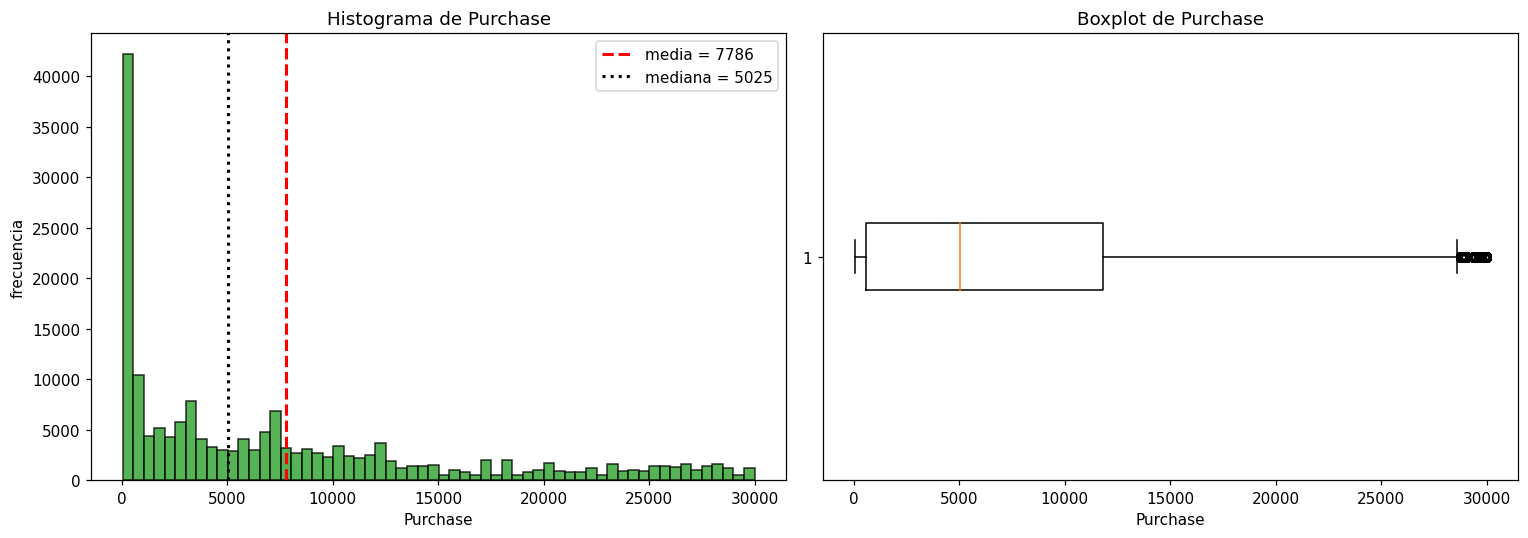

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df["Purchase"], bins=60, color="tab:green", edgecolor="black", alpha=0.8)
ax1.axvline(df["Purchase"].mean(), color="red", ls="--", lw=2, label=f"media = {df['Purchase'].mean():.0f}")
ax1.axvline(df["Purchase"].median(), color="black", ls=":", lw=2, label=f"mediana = {df['Purchase'].median():.0f}")
ax1.set_title("Histograma de Purchase")
ax1.set_xlabel("Purchase")
ax1.set_ylabel("frecuencia")
ax1.legend()

ax2.boxplot(df["Purchase"], vert=False)
ax2.set_title("Boxplot de Purchase")
ax2.set_xlabel("Purchase")

plt.tight_layout()
plt.show()

In [32]:
print(df["Purchase"].describe().round(2))

count    180472.00
mean       7786.44
std        8286.98
min          45.00
25%         574.00
50%        5025.00
75%       11799.00
max       29980.00
Name: Purchase, dtype: float64


Veo que para `Purchase` hay muchas compras chicas y unas pocas grandes que estiran la distribución, sesgándola a la derecha, ya que la media queda por encima de la mediana y el boxplot muestra una cola larga hacia los montos altos.

Este `Purchase` no es mi target final, ya que es por transacción y mi objetivo es predecir el gasto promedio por cliente (varias transacciones).

## Distribución de las variables categóricas

Miro cuánto pesa cada valor dentro de las variables cualitativas, para detectar categorías raras o desbalanceadas antes de modelar.

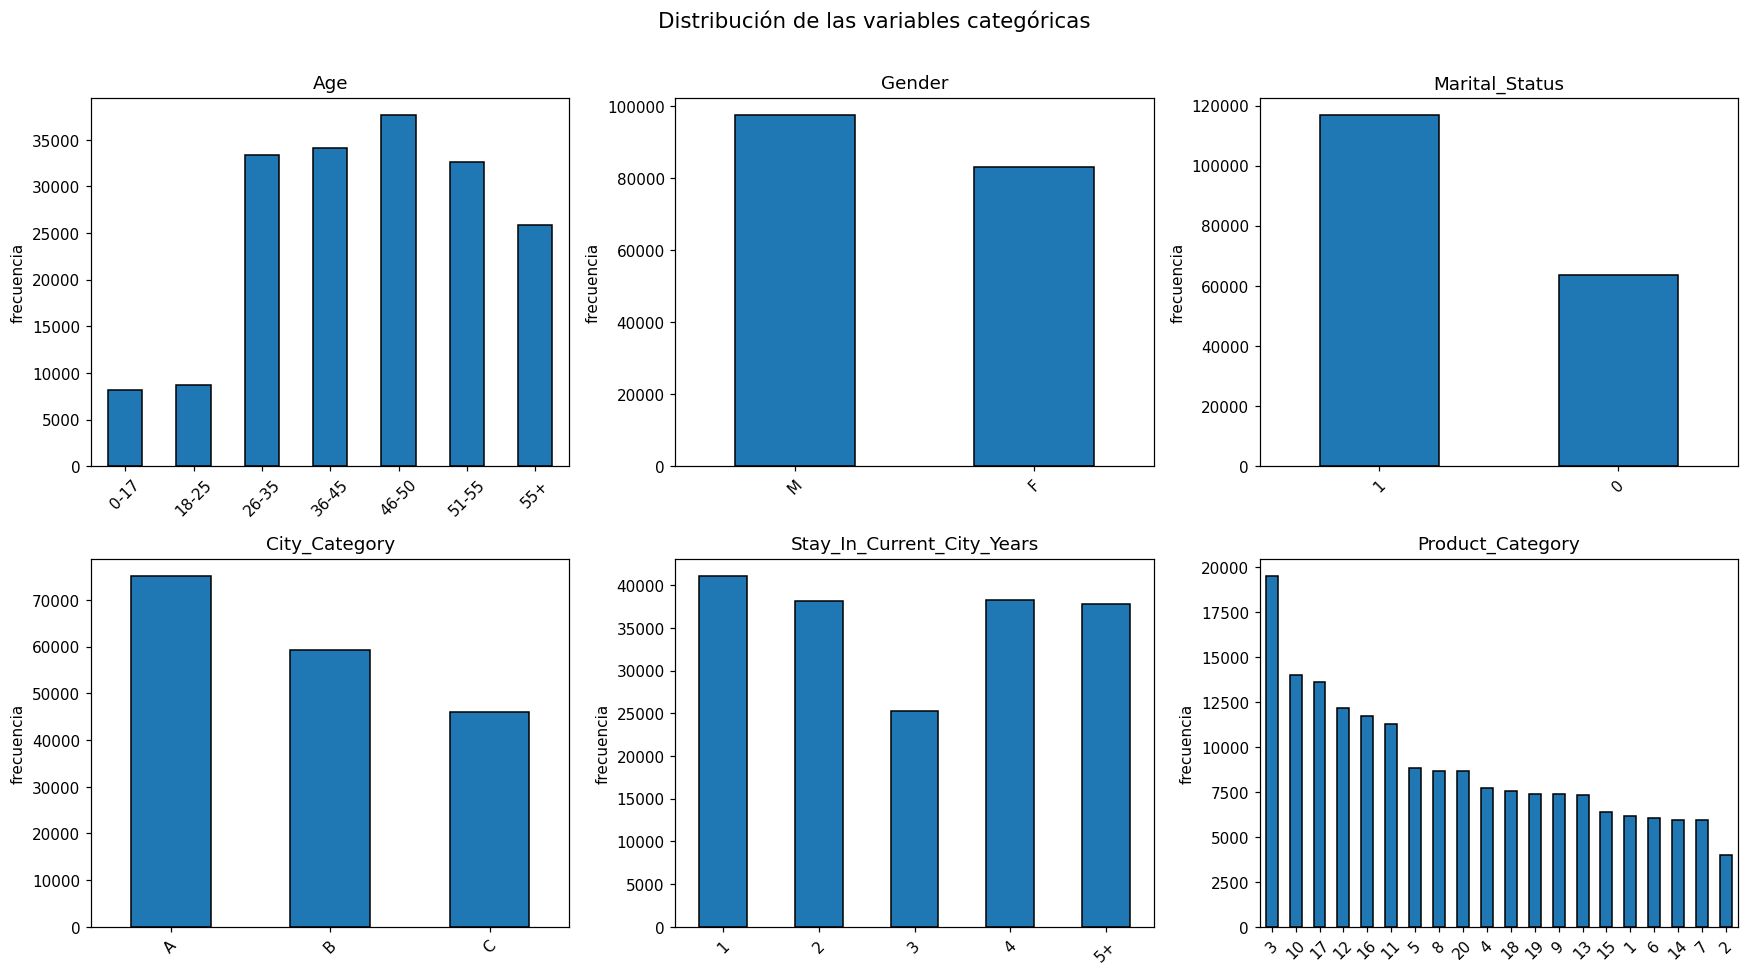

In [33]:
# Distribución de cada variable categórica / discreta
orden_age = ["0-17", "18-25", "26-35", "36-45", "46-50", "51-55", "55+"]
orden_stay = ["1", "2", "3", "4", "5+"]

cats = {
    "Age": orden_age,
    "Gender": None,
    "Marital_Status": None,
    "City_Category": ["A", "B", "C"],
    "Stay_In_Current_City_Years": orden_stay,
    "Product_Category": None,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (col, orden) in zip(axes.flat, cats.items()):
    vc = df[col].value_counts()
    if orden is not None:
        vc = vc.reindex(orden)
    vc.plot(kind="bar", ax=ax, color="tab:blue", edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("frecuencia")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Distribución de las variables categóricas", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**Qué veo en las categóricas**

- `Age`: la tienda concentra clientes de mediana edad. Los rangos `26-35`, `36-45` y `46-50` son los más poblados, mientras que `0-17` y `18-25` casi no aparecen.
- `Gender`: hay algo más de hombres que de mujeres, sin un desbalance grave.
- `Marital_Status`: predominan los casados (1) sobre los solteros (0), cerca de 2 a 1.
- `City_Category`: las tres zonas están representadas, con la zona `A` (clase alta) a la cabeza.
- `Stay_In_Current_City_Years`: los años de antigüedad están bastante repartidos.
- `Product_Category`: 20 categorías con una cola larga. Unas pocas (3, 10, 17, 12) explican buena parte de las compras.

## Transacciones por cliente

Antes de armar los datos miro cuántas compras tiene cada cliente, porque la consigna dice que el modelo se usará sobre clientes nuevos con apenas 3-5 visitas, así que quiero ver si mis clientes se parecen a ese escenario o no.

In [34]:
tx_por_cliente = df.groupby("User_ID").size()

print(tx_por_cliente.describe().round(1))
print("\nClientes con 5 transacciones o menos:", (tx_por_cliente <= 5).sum())

count    7432.0
mean       24.3
std        13.4
min         9.0
25%        14.0
50%        18.0
75%        39.0
max        50.0
dtype: float64

Clientes con 5 transacciones o menos: 0


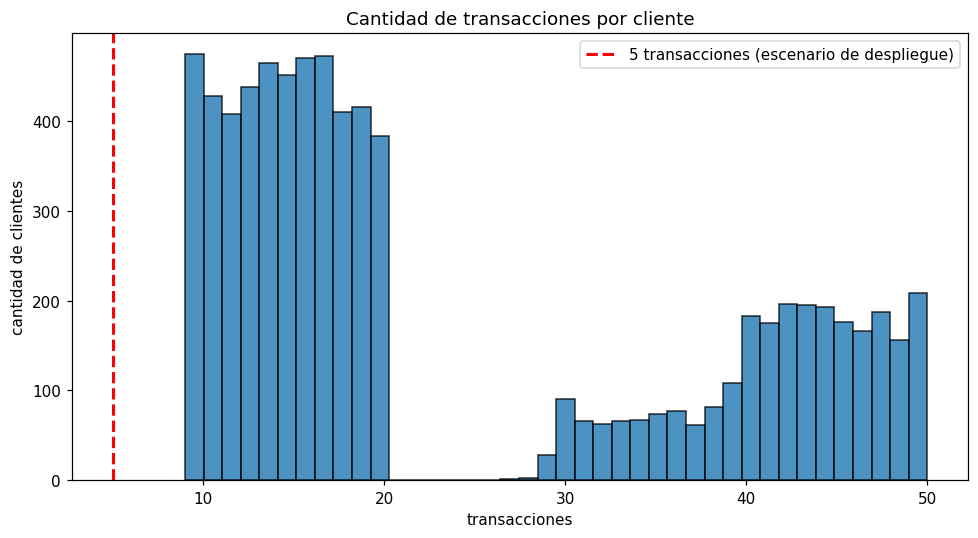

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(tx_por_cliente, bins=40, color="tab:blue", edgecolor="black", alpha=0.8)
ax.axvline(5, color="red", ls="--", lw=2, label="5 transacciones (escenario de despliegue)")
ax.set_title("Cantidad de transacciones por cliente")
ax.set_xlabel("transacciones")
ax.set_ylabel("cantidad de clientes")
ax.legend()
plt.tight_layout()
plt.show()

Todos mis clientes tienen varias transacciones. El que menos compras tiene llega a 9 y ningún cliente tiene 5 transacciones o menos, es decir, ninguno se parece al cliente nuevo sobre el que el modelo va a predecir. Lo que voy a hacer es entrenar el modelo con el historial de transacciones completo para aprovechar toda la información, y después de evaluarlo dedico una sección aparte a medir qué pasa cuando solo se observan 3-5 compras, que es el escenario real de uso.

## Transformaciones y *feature engineering*

Hasta recién trabajé sobre las transacciones, pero el objetivo es predecir el gasto promedio por cliente. Así que armo una fila por `User_ID`, con el nuevo target:

`gasto_promedio` = promedio de `Purchase` de todo su historial.

Para evitar data leakage, ningún feature usa el promedio ni el total del monto (serían el target adentro de X). Sí uso el máximo, mínimo y desvío de `Purchase`, que describen la forma del gasto pero no son el promedio. Las proporciones `prop_cat_*` son de cantidad de compras. Además el split se hace por cliente, así ninguno cae en train y test a la vez.


**Features:**

- **Demográficos:** `Age`, `Gender`, `Marital_Status`, `City_Category`, `Stay_In_Current_City_Years`.
- **Comportamiento:**
    - `n_categorias`: categorías distintas que compró
    - `categoria_fav`: categoría más comprada
    - `gasto_max`, `gasto_min`: monto máximo y mínimo histórico
    - `gasto_std`: desvío del gasto (qué tan diversas son sus compras)
- **Gustos:** `prop_cat_*`, la proporción de compras en cada categoría.

**Encoding**:

| Variable | Encoding | Por qué |
|---|---|---|
| `Age` | ordinal 0..6 | Los rangos tienen orden (`0-17` < ... < `55+`). |
| `Stay_In_Current_City_Years` | ordinal 0..4 | Los años tienen orden; `5+` es el tope. |
| `City_Category` | ordinal (A>B>C) | A/B/C es un nivel socioeconómico, tiene orden. |
| `Gender` | label (F/M → 0/1) | Solo dos valores. |
| `Marital_Status` | ya es 0/1 | Viene numérica binaria. |
| `categoria_fav` | one-hot | 20 categorías sin orden. |

In [36]:
demograf = ["Age", "Gender", "Marital_Status", "City_Category", "Stay_In_Current_City_Years"]

# Tabla auxiliar con el nuevo target para hacer el split.
target_cli = df.groupby("User_ID").agg(
    gasto_promedio=("Purchase", "mean"),
    **{c: (c, "first") for c in demograf},
)
# Cuantiles de gasto promedio para estratificar el split por cliente
target_cli["_bin"] = pd.qcut(target_cli["gasto_promedio"], q=5, labels=False)
print(f"Clientes totales: {len(target_cli)}")
target_cli.head()

Clientes totales: 7432


,gasto_promedio,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,_bin
User_ID,,,,,,,
1000035,1912.923077,18-25,M,0,A,1,0
1000044,14338.906977,36-45,M,1,A,4,4
1000070,4120.809524,46-50,M,1,B,4,1
1000087,10794.925000,55+,F,1,C,4,4
1000115,4673.882353,46-50,F,1,C,2,1


In [37]:
print("Gasto promedio por cliente (target):")
print(target_cli["gasto_promedio"].describe().round(0))

Gasto promedio por cliente (target):
count     7432.0
mean      6725.0
std       3253.0
min        275.0
25%       4255.0
50%       6330.0
75%       8522.0
max      17308.0
Name: gasto_promedio, dtype: float64


In [38]:
ids_train, ids_test = train_test_split(
    target_cli.index, test_size=0.2, random_state=42, stratify=target_cli["_bin"]
)
ids_train, ids_test = list(ids_train), list(ids_test)
print(f"Clientes -> train: {len(ids_train)} | test: {len(ids_test)}")

Clientes -> train: 5945 | test: 1487


In [39]:
cats_all = sorted(df["Product_Category"].unique())  # (para las columnas prop_cat_*)
idx_por_cliente = {u: g.index.values for u, g in df.groupby("User_ID")}

def construir_clientes(ids, seed=None, k_max=None):
    """
        Construye la tabla de clientes (una fila por User_ID).
        - k_max=None: usa todas las transacciones del cliente para los features.
        - k_max=(3, 5): submuestrea entre 3 y 5 transacciones (escenario de clientes nuevos).
        Los features son los mismos en ambos casos; lo único que cambia es cuántas
        transacciones se usan para calcularlos. El target siempre es el gasto promedio
        real sobre toda la historia.
    """
    rng = np.random.RandomState(seed)
    filas = []
    for u in ids:
        idxs = idx_por_cliente[u]
        if k_max is None:
            # historial completo
            muestra = df.loc[idxs]
            k = len(idxs)
        else:
            # muestreo aleatoriamente k (3-5) transacciones del cliente
            k = min(rng.randint(k_max[0], k_max[1] + 1), len(idxs))
            muestra = df.loc[rng.choice(idxs, size=k, replace=False)]

        fila = {"User_ID": u}

        # calculo features del cliente
        fila.update({c: muestra[c].iloc[0] for c in demograf})
        fila["n_categorias"] = muestra["Product_Category"].nunique()
        fila["categoria_fav"] = muestra["Product_Category"].mode().iloc[0]
        fila["gasto_max"] = muestra["Purchase"].max()
        fila["gasto_min"] = muestra["Purchase"].min()
        fila["gasto_std"] = muestra["Purchase"].std(ddof=0)

        # calculo gusto: qué proporción de las compras cae en cada categoría
        vc = muestra["Product_Category"].value_counts(normalize=True)
        for c in cats_all:
            fila[f"prop_cat_{c}"] = vc.get(c, 0.0)

        # target: promedio real de todas sus transacciones
        fila["gasto_promedio"] = target_cli.loc[u, "gasto_promedio"]
        filas.append(fila)
    return pd.DataFrame(filas)

train_cli = construir_clientes(ids_train)
test_cli = construir_clientes(ids_test)

In [40]:
print("train_cli:", train_cli.shape)
train_cli.head()

train_cli: (5945, 32)


,User_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,n_categorias,categoria_fav,gasto_max,gasto_min,gasto_std,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20,gasto_promedio
0,1081994,26-35,M,0,B,1,10,10,26960,107,8421.093955,0.000000,0.071429,0.000000,0.000000,0.071429,0.000000,0.071429,0.071429,0.000000,0.142857,0.142857,0.142857,0.000000,0.000000,0.000000,0.071429,0.000000,0.000000,0.142857,0.071429,8371.500000
1,1024167,36-45,M,1,A,1,17,20,28570,122,9806.675825,0.000000,0.023256,0.093023,0.000000,0.000000,0.023256,0.046512,0.046512,0.046512,0.046512,0.046512,0.023256,0.046512,0.023256,0.069767,0.069767,0.046512,0.046512,0.139535,0.162791,12081.674419
2,1079723,46-50,F,1,C,2,7,16,24070,79,6156.847359,0.000000,0.000000,0.000000,0.000000,0.214286,0.000000,0.000000,0.071429,0.000000,0.142857,0.000000,0.000000,0.071429,0.071429,0.000000,0.285714,0.142857,0.000000,0.000000,0.000000,2855.142857
3,1003912,0-17,M,0,A,2,9,10,23880,134,6654.739642,0.090909,0.090909,0.090909,0.090909,0.000000,0.000000,0.000000,0.000000,0.000000,0.181818,0.000000,0.000000,0.090909,0.000000,0.090909,0.181818,0.090909,0.000000,0.000000,0.000000,3371.454545
4,1038453,46-50,M,1,B,5+,15,3,26920,348,5628.737659,0.020408,0.040816,0.163265,0.000000,0.000000,0.040816,0.081633,0.081633,0.081633,0.081633,0.081633,0.142857,0.061224,0.061224,0.020408,0.000000,0.020408,0.020408,0.000000,0.000000,7416.040816


In [41]:
print("test_cli:", test_cli.shape)
test_cli.head()

test_cli: (1487, 32)


,User_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,n_categorias,categoria_fav,gasto_max,gasto_min,gasto_std,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20,gasto_promedio
0,1042228,36-45,M,0,B,1,12,4,12258,96,3554.567185,0.062500,0.062500,0.062500,0.125000,0.062500,0.062500,0.000000,0.000000,0.000000,0.062500,0.062500,0.062500,0.000000,0.000000,0.125000,0.125000,0.125000,0.000000,0.000000,0.0,2661.437500
1,1070537,26-35,M,0,B,1,7,17,23060,265,6425.290628,0.000000,0.090909,0.090909,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.181818,0.090909,0.000000,0.000000,0.000000,0.000000,0.181818,0.272727,0.090909,0.000000,0.0,3697.727273
2,1049628,18-25,M,0,A,2,10,15,26050,85,7528.521067,0.000000,0.000000,0.076923,0.000000,0.076923,0.076923,0.076923,0.000000,0.076923,0.076923,0.000000,0.000000,0.000000,0.000000,0.230769,0.076923,0.153846,0.000000,0.076923,0.0,4941.076923
3,1044346,51-55,F,1,C,2,8,12,29870,2817,5754.272006,0.105263,0.000000,0.210526,0.000000,0.000000,0.105263,0.052632,0.000000,0.000000,0.000000,0.052632,0.368421,0.052632,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000,0.0,9066.684211
4,1054075,55+,F,1,C,5+,17,11,28350,185,7853.550173,0.025641,0.025641,0.025641,0.051282,0.000000,0.102564,0.051282,0.076923,0.025641,0.025641,0.153846,0.051282,0.025641,0.025641,0.000000,0.076923,0.153846,0.025641,0.076923,0.0,8022.128205


Ahora aplicamos el encoding definido en la tabla de arriba, haciendo `fit` solo con train para evitar data leakeage

In [42]:
# Mappings ordinales/binarios
map_age = {"0-17": 0, "18-25": 1, "26-35": 2, "36-45": 3, "46-50": 4, "51-55": 5, "55+": 6}
map_gender = {"F": 0, "M": 1}
map_city = {"A": 2, "B": 1, "C": 0}  # A > B > C
map_city_stay = {"1": 0, "2": 1, "3": 2, "4": 3, "5+": 4}

def aplicar_mappings(d):
    d = d.copy()
    d["Age"] = d["Age"].map(map_age)
    d["Stay_In_Current_City_Years"] = d["Stay_In_Current_City_Years"].map(map_city_stay)
    d["City_Category"] = d["City_Category"].map(map_city)
    d["Gender"] = d["Gender"].map(map_gender)
    return d

train_cli = aplicar_mappings(train_cli)
test_cli = aplicar_mappings(test_cli)

Separo validación antes de ajustar one-hot y scaler, para que val no filtre en el preprocesamiento (data leakage)

In [43]:
train_fit, train_val = train_test_split(train_cli, test_size=0.1, random_state=0)

In [44]:
def sep_xy(d):
    y = d["gasto_promedio"].values
    X = d.drop(columns=["User_ID", "gasto_promedio"])
    return X, y

X_fit, y_fit = sep_xy(train_fit)
X_val, y_val = sep_xy(train_val)
X_test, y_test = sep_xy(test_cli)

# alineo columnas de val y test al orden de X_fit
X_val = X_val[X_fit.columns]
X_test = X_test[X_fit.columns]

In [45]:
print("X_fit:", X_fit.shape)
X_fit.head()

X_fit: (5350, 30)


,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,n_categorias,categoria_fav,gasto_max,gasto_min,gasto_std,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20
2374,6,0,1,0,4,11,15,22340,54,6047.246736,0.058824,0.058824,0.058824,0.058824,0.117647,0.000000,0.058824,0.000000,0.000000,0.000000,0.000000,0.117647,0.000000,0.000000,0.176471,0.058824,0.176471,0.000000,0.000000,0.058824
1262,5,0,1,1,4,19,19,27830,70,8343.123053,0.066667,0.044444,0.022222,0.044444,0.000000,0.044444,0.022222,0.044444,0.022222,0.088889,0.044444,0.066667,0.044444,0.022222,0.022222,0.022222,0.066667,0.111111,0.133333,0.066667
1431,4,1,1,1,4,15,11,25790,163,5736.913689,0.046512,0.046512,0.046512,0.000000,0.000000,0.023256,0.069767,0.093023,0.093023,0.116279,0.139535,0.046512,0.000000,0.046512,0.000000,0.093023,0.093023,0.023256,0.023256,0.000000
3416,0,1,0,2,0,6,10,11389,179,3560.764212,0.000000,0.000000,0.076923,0.000000,0.000000,0.000000,0.000000,0.076923,0.000000,0.538462,0.076923,0.153846,0.000000,0.000000,0.000000,0.000000,0.076923,0.000000,0.000000,0.000000
4129,3,1,0,1,1,8,10,10706,130,2657.476090,0.000000,0.071429,0.000000,0.214286,0.071429,0.000000,0.071429,0.071429,0.000000,0.285714,0.000000,0.000000,0.000000,0.000000,0.000000,0.071429,0.142857,0.000000,0.000000,0.000000


In [46]:
print("X_val:", X_val.shape)
X_val.head()

X_val: (595, 30)


,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,n_categorias,categoria_fav,gasto_max,gasto_min,gasto_std,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20
134,4,0,1,1,0,8,4,6883,239,2220.200106,0.000000,0.000000,0.000000,0.181818,0.090909,0.0000,0.000000,0.000000,0.000000,0.090909,0.181818,0.000000,0.000000,0.090909,0.181818,0.090909,0.090909,0.000000,0.000000,0.000000
1364,4,0,1,1,2,15,3,27630,73,10088.965906,0.000000,0.033333,0.166667,0.000000,0.100000,0.0000,0.000000,0.066667,0.033333,0.033333,0.033333,0.033333,0.100000,0.000000,0.033333,0.066667,0.033333,0.133333,0.100000,0.033333
555,2,1,0,2,1,10,12,29870,572,7895.849216,0.076923,0.153846,0.076923,0.076923,0.000000,0.0000,0.076923,0.076923,0.076923,0.000000,0.076923,0.230769,0.076923,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4139,2,1,0,2,0,14,12,29660,130,9005.241338,0.000000,0.088235,0.117647,0.000000,0.029412,0.0000,0.000000,0.029412,0.000000,0.000000,0.058824,0.176471,0.117647,0.029412,0.058824,0.029412,0.029412,0.058824,0.088235,0.088235
2857,2,1,0,2,3,7,12,19810,626,4025.463651,0.125000,0.000000,0.000000,0.000000,0.000000,0.1875,0.000000,0.000000,0.062500,0.000000,0.187500,0.250000,0.000000,0.000000,0.000000,0.062500,0.000000,0.125000,0.000000,0.000000


In [47]:
print("X_test:", X_test.shape)
X_test.head()

X_test: (1487, 30)


,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,n_categorias,categoria_fav,gasto_max,gasto_min,gasto_std,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20
0,3,1,0,1,0,12,4,12258,96,3554.567185,0.062500,0.062500,0.062500,0.125000,0.062500,0.062500,0.000000,0.000000,0.000000,0.062500,0.062500,0.062500,0.000000,0.000000,0.125000,0.125000,0.125000,0.000000,0.000000,0.0
1,2,1,0,1,0,7,17,23060,265,6425.290628,0.000000,0.090909,0.090909,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.181818,0.090909,0.000000,0.000000,0.000000,0.000000,0.181818,0.272727,0.090909,0.000000,0.0
2,1,1,0,2,1,10,15,26050,85,7528.521067,0.000000,0.000000,0.076923,0.000000,0.076923,0.076923,0.076923,0.000000,0.076923,0.076923,0.000000,0.000000,0.000000,0.000000,0.230769,0.076923,0.153846,0.000000,0.076923,0.0
3,5,0,1,0,1,8,12,29870,2817,5754.272006,0.105263,0.000000,0.210526,0.000000,0.000000,0.105263,0.052632,0.000000,0.000000,0.000000,0.052632,0.368421,0.052632,0.000000,0.000000,0.000000,0.052632,0.000000,0.000000,0.0
4,6,0,1,0,4,17,11,28350,185,7853.550173,0.025641,0.025641,0.025641,0.051282,0.000000,0.102564,0.051282,0.076923,0.025641,0.025641,0.153846,0.051282,0.025641,0.025641,0.000000,0.076923,0.153846,0.025641,0.076923,0.0


Aplicamos el OneHot

In [48]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=int)
ohe.fit(X_fit[["categoria_fav"]])

def aplicar_ohe(d):
    arr = ohe.transform(d[["categoria_fav"]])
    cols = [f"catfav_{int(c)}" for c in ohe.categories_[0]]
    return pd.concat(
        [d.drop(columns="categoria_fav"), pd.DataFrame(arr, columns=cols, index=d.index)],
        axis=1
    )

X_fit = aplicar_ohe(X_fit)
X_val = aplicar_ohe(X_val)
X_test = aplicar_ohe(X_test)

In [49]:
print(X_fit.shape, y_fit.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(5350, 49) (5350,)
(595, 49) (595,)
(1487, 49) (1487,)


Escalo las continuas y ordinales para que el gradient descent converja más rápido. Binarias y one-hot quedan en 0-1.

In [50]:
cont = (
      ["Age", "Stay_In_Current_City_Years", "City_Category", "n_categorias", "gasto_max", "gasto_min", "gasto_std"]
      + [c for c in X_fit.columns if c.startswith("prop_cat_")]
)

scaler = StandardScaler().fit(X_fit[cont])

X_fit = X_fit.copy();  X_fit[cont]  = scaler.transform(X_fit[cont])
X_val = X_val.copy();  X_val[cont]  = scaler.transform(X_val[cont])
X_test = X_test.copy(); X_test[cont] = scaler.transform(X_test[cont])

In [51]:
print(X_fit.shape, y_fit.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(5350, 49) (5350,)
(595, 49) (595,)
(1487, 49) (1487,)


In [52]:
print(f"Nulos: fit {X_fit.isna().sum().sum()}, val {X_val.isna().sum().sum()}, test {X_test.isna().sum().sum()}")
print(f"Chequeo fit escalado: media ~ {round(X_fit[cont].mean().mean(), 3)} | std ~ {round(X_fit[cont].std().mean(), 3)}")
print(f"Chequeo val escalado: media ~ {round(X_val[cont].mean().mean(), 3)} | std ~ {round(X_val[cont].std().mean(), 3)}")
print(f"Chequeo test escalado: media ~ {round(X_test[cont].mean().mean(), 3)} | std ~ {round(X_test[cont].std().mean(), 3)}")

Nulos: fit 0, val 0, test 0
Chequeo fit escalado: media ~ 0.0 | std ~ 1.0
Chequeo val escalado: media ~ 0.007 | std ~ 1.017
Chequeo test escalado: media ~ -0.001 | std ~ 0.996


In [53]:
X_fit.head()

,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,n_categorias,gasto_max,gasto_min,gasto_std,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20,catfav_1,catfav_2,catfav_3,catfav_4,catfav_5,catfav_6,catfav_7,catfav_8,catfav_9,catfav_10,catfav_11,catfav_12,catfav_13,catfav_14,catfav_15,catfav_16,catfav_17,catfav_18,catfav_19,catfav_20
2374,1.498272,0,1,-1.385072,1.660715,-0.190829,-0.162680,-0.389941,-0.360092,0.607566,1.267780,-0.479076,0.033824,0.729830,-0.743672,0.643989,-0.913327,-0.815295,-1.155096,-0.971937,0.843229,-0.757570,-0.739005,2.221262,-0.217559,1.219080,-0.750150,-0.762917,0.402490,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1262,0.929859,0,1,-0.144674,1.660715,2.023181,0.655212,-0.342831,0.682586,0.788276,0.805820,-0.985509,-0.176267,-0.882902,0.315041,-0.215339,0.008563,-0.354096,0.003649,-0.237811,0.040973,0.261713,-0.218638,-0.404159,-0.740298,-0.256922,1.733359,2.281091,0.561768,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1431,0.361447,1,1,-0.144674,1.660715,0.916176,0.351296,-0.069004,-0.501031,0.323895,0.872233,-0.649429,-0.825639,-0.882902,-0.189694,0.900932,1.016209,1.115306,0.360704,1.332875,-0.276198,-0.757570,0.350135,-0.782397,0.270882,0.097368,-0.230346,-0.231985,-0.792096,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3416,-1.912204,1,0,1.095723,-1.144724,-1.574585,-1.794143,-0.021894,-1.489335,-0.747752,-0.622055,-0.228641,-0.825639,-0.882902,-0.743672,-0.737074,0.682251,-0.815295,5.864224,0.298665,1.412878,-0.757570,-0.739005,-0.782397,-1.057676,-0.119054,-0.750150,-0.762917,-0.792096,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4129,-0.206966,1,0,-0.144674,-0.443364,-1.021083,-1.895895,-0.166168,-1.899565,-0.747752,1.672744,-1.292987,2.305261,0.096257,-0.743672,0.939932,0.568281,-0.815295,2.569441,-0.971937,-1.008131,-0.757570,-0.739005,-0.782397,-0.037533,0.767243,-0.750150,-0.762917,-0.792096,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [54]:
X_val.head()

,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,n_categorias,gasto_max,gasto_min,gasto_std,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20,catfav_1,catfav_2,catfav_3,catfav_4,catfav_5,catfav_6,catfav_7,catfav_8,catfav_9,catfav_10,catfav_11,catfav_12,catfav_13,catfav_14,catfav_15,catfav_16,catfav_17,catfav_18,catfav_19,catfav_20
134,0.361447,0,1,-0.144674,-1.144724,-1.021083,-2.465439,0.154769,-2.098155,-0.747752,-0.622055,-1.292987,1.830882,0.363300,-0.743672,-0.737074,-0.913327,-0.815295,0.029984,2.031303,-1.008131,-0.757570,1.389768,2.312282,0.240687,0.068949,-0.750150,-0.762917,-0.792096,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1364,0.361447,0,1,-0.144674,0.257996,0.916176,0.625416,-0.333998,1.475465,-0.747752,0.448851,1.013095,-0.825639,0.487920,-0.743672,-0.737074,0.469507,-0.123496,-0.720567,-0.421343,-0.483579,1.535816,-0.739005,-0.215039,-0.105543,-0.704994,2.230061,1.520089,-0.115164,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
555,-0.775378,1,0,1.095723,-0.443364,-0.467580,0.959128,1.135249,0.479456,1.024588,4.320589,-0.228641,0.298274,-0.882902,-0.743672,1.068932,0.682251,0.781163,-1.155096,0.298665,2.623382,1.006573,-0.739005,-0.782397,-1.057676,-1.153066,-0.750150,-0.762917,-0.792096,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4139,-0.775378,1,0,1.095723,-1.144724,0.639425,0.927842,-0.166168,0.983289,-0.747752,2.212697,0.334836,-0.825639,-0.479719,-0.743672,-0.737074,-0.303253,-0.815295,-1.155096,-0.000300,1.768908,1.940531,-0.050284,0.218823,-0.637617,-0.757708,0.564649,1.251500,0.999783,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2857,-0.775378,1,0,1.095723,0.959355,-1.297834,-0.539595,1.294246,-1.278290,2.132300,-0.622055,-1.292987,-0.825639,-0.882902,3.722771,-0.737074,-0.913327,0.481827,-1.155096,2.125155,2.926008,-0.757570,-0.739005,-0.782397,-0.165051,-1.153066,2.043798,-0.762917,-0.792096,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [55]:
X_test.head()

,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,n_categorias,gasto_max,gasto_min,gasto_std,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20,catfav_1,catfav_2,catfav_3,catfav_4,catfav_5,catfav_6,catfav_7,catfav_8,catfav_9,catfav_10,catfav_11,catfav_12,catfav_13,catfav_14,catfav_15,catfav_16,catfav_17,catfav_18,catfav_19,catfav_20
0,-0.206966,1,0,-0.144674,-1.144724,0.085922,-1.664680,-0.266277,-1.492149,0.692274,1.385894,-0.428206,1.000719,-0.026138,0.745143,-0.737074,-0.913327,-0.815295,-0.340354,0.060427,-0.024596,-0.757570,-0.739005,1.345195,0.727574,0.527204,-0.750150,-0.762917,-0.792096,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,-0.775378,1,0,-0.144674,-1.144724,-1.297834,-0.055415,0.231323,-0.188403,-0.747752,2.298598,-0.035124,-0.825639,-0.882902,-0.743672,-0.737074,-0.913327,-0.815295,1.215064,0.529683,-1.008131,-0.757570,-0.739005,-0.782397,1.539051,2.512978,1.281812,-0.762917,-0.792096,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,-1.343791,1,0,1.095723,-0.443364,-0.467580,0.390030,-0.298666,0.312633,-0.747752,-0.622055,-0.228641,-0.825639,0.171577,1.088715,1.068932,-0.913327,0.781163,-0.152336,-0.971937,-1.008131,-0.757570,-0.739005,3.145466,0.040939,0.914959,-0.750150,0.993241,-0.792096,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0.929859,0,1,-1.385072,-0.443364,-1.021083,0.959128,7.745388,-0.493147,1.677555,-0.622055,1.619959,-0.825639,-0.882902,1.763805,0.498614,-0.913327,-0.815295,-1.155096,-0.102578,4.789547,0.449475,-0.739005,-0.782397,-1.057676,-0.445584,-0.750150,-0.762917,-0.792096,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,1.498272,0,1,-1.385072,1.660715,1.469678,0.732680,-0.004227,0.460245,-0.156972,0.201719,-0.938205,-0.076364,-0.882902,1.699511,0.466930,0.682251,-0.283142,-0.820843,1.569266,-0.201128,-0.169522,-0.138582,-0.782397,0.040939,0.914959,-0.177032,0.993241,-0.792096,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


Con esto quedan los datos listos para entrenar el modelo

### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

In [56]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
import optuna

torch.manual_seed(0)
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [57]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Success: MPS from Apple is available!")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Success: CUDA is available!")
else:
    device = torch.device("cpu")
    print("No GPU acceleration available. Defaulting to CPU.")

Success: MPS from Apple is available!


In [58]:
# Pasamos los datos a tensores de torch (float32) y al device. El target va como columna (N, 1).
def a_tensor(X, y):
    Xt = torch.tensor(np.asarray(X, dtype=np.float32), device=device)
    yt = torch.tensor(np.asarray(y, dtype=np.float32).reshape(-1, 1), device=device)
    return Xt, yt

X_fit_t, y_fit_t = a_tensor(X_fit, y_fit)
X_val_t, y_val_t = a_tensor(X_val, y_val)
X_test_t, y_test_t = a_tensor(X_test, y_test)

In [59]:
print(f"fit: {tuple(X_fit_t.shape)}")
print(f"val: {tuple(X_val_t.shape)}")
print(f"test: {tuple(X_test_t.shape)}")

fit: (5350, 49)
val: (595, 49)
test: (1487, 49)


In [60]:
batch_size = 256  # potencia de 2 (eficiente en hardware), y con ~5.350 filas da ~21 batches/época
ds = TensorDataset(X_fit_t, y_fit_t)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

### Arquitectura

Decisiones:
* Uso 3 capas ocultas de 128, 64 y 32 neuronas.
* La salida es lineal, porque en regresión la capa de salida va sin función de activación, ya que no quiero acotar el rango del valor predicho, como sí harían una sigmoid o una softmax.
* Optimizador: Adam. Es el estándar y el más poderoso de los presentados por la cátedra. En la Pregunta 1 lo evalué de forma empírica contra otras opciones.
* Función de costo: MSE, porque es una regresión, ya que predigo una variable continua (el gasto).
* Para leer resultados reporto RMSE (raíz del MSE), que queda en la misma escala que el target.
* Activación: ReLU en las capas ocultas, que es la que la clase marca como default seguro para capas ocultas de redes profundas cuando no hay una razón específica para elegir otra. Es simple y rápida. Abajo la comparo empíricamente contra tanh.

In [61]:
def construir_mlp(n_entradas):
    """MLP de 3 capas ocultas (128 -> 64 -> 32) con ReLU y salida lineal."""
    return nn.Sequential(
        nn.Linear(n_entradas, 128), nn.ReLU(),
        nn.Linear(128, 64), nn.ReLU(),
        nn.Linear(64, 32), nn.ReLU(),
        nn.Linear(32, 1),
    ).to(device)

def entrenar(model, dl, lr, epochs, datos_val=None, datos_fit=None, verbose=False):
    """
    Entrena con Adam + MSE. Si se pasan datos_val (y datos_fit) guarda por época las
    curvas de MSE y R² y las devuelve en un dict; si no, las listas quedan vacías.
    """
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    L = nn.MSELoss()
    hist = {"loss": [], "val_loss": [], "r2_tr": [], "r2_val": []}
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in dl:
            loss = L(model(xb), yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(dl.dataset)

        if datos_val is not None:
            model.eval()
            with torch.no_grad():
                Xv, yv = datos_val
                vl = L(model(Xv), yv).item()
                hist["loss"].append(epoch_loss)
                hist["val_loss"].append(vl)
                if datos_fit is not None:
                    Xf, yf = datos_fit
                    hist["r2_tr"].append(r2_score(yf.cpu().numpy(), model(Xf).cpu().numpy()))
                    hist["r2_val"].append(r2_score(yv.cpu().numpy(), model(Xv).cpu().numpy()))
                if verbose and (epoch + 1) % 10 == 0:
                    r2v = hist["r2_val"][-1] if hist["r2_val"] else float("nan")
                    print(f"época {epoch+1:3d} | RMSE train {epoch_loss**0.5:.0f} | RMSE val {vl**0.5:.0f} | R² val {r2v:.3f}")
    return hist

mse_loss = nn.MSELoss()

Para validar la elección con datos y no solo con teoría, entreno la misma red dos veces con un setup corto e idéntico (40 épocas, lr = 1e-3, misma semilla): una con ReLU y otra con tanh. Comparo el error en validación.

In [ ]:
# Misma arquitectura, solo cambia la activación de las capas ocultas
def construir_mlp_act(n_entradas, Act):
    return nn.Sequential(
        nn.Linear(n_entradas, 128), Act(),
        nn.Linear(128, 64), Act(),
        nn.Linear(64, 32), Act(),
        nn.Linear(32, 1),
    ).to(device)

filas_act = []
for nombre_act, Act in [("ReLU", nn.ReLU), ("Tanh", nn.Tanh)]:
    torch.manual_seed(0)
    m_act = construir_mlp_act(X_fit_t.shape[1], Act)
    entrenar(m_act, dl, lr=1e-3, epochs=40)
    m_act.eval()
    with torch.no_grad():
        pred_v = m_act(X_val_t)
        mse_v = mse_loss(pred_v, y_val_t).item()
        r2_v = r2_score(y_val_t.cpu().numpy().ravel(), pred_v.cpu().numpy().ravel())
    filas_act.append({"activacion": nombre_act, "MSE val": round(mse_v),
                      "RMSE val": round(mse_v ** 0.5), "R2 val": round(r2_v, 3)})

pd.DataFrame(filas_act)

,activacion,MSE val,RMSE val,R2 val
0,ReLU,504012,710,0.949
1,Tanh,54743640,7399,-4.541


Con el mismo entrenamiento corto, ReLU llega a un R² de validación alto mientras que tanh queda con R² negativo, es decir, peor que predecir siempre el promedio. Tiene sentido: tanh acota las activaciones a (-1, 1), así que toda la escala del target (~6.700) tiene que salir de los pesos de la capa final. Con más épocas y otro learning rate tanh quizas mejoraría, pero ReLU no tiene ese problema y es más barata de computar. Me quedo con ReLU.

El learning rate y la cantidad de épocas impactan en el entrenamiento, así que en lugar de fijarlos a mano hago una búsqueda con Optuna:
* `lr` en escala logarítmica entre `1e-4` y `1e-2`
* `epochs` entre 20 y 120.

In [ ]:
def objetivo(trial):
    lr_t = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    epochs_t = trial.suggest_int("epochs", 20, 120)
    torch.manual_seed(0)
    m = construir_mlp(X_fit_t.shape[1])
    entrenar(m, dl, lr_t, epochs_t)  # entrena sin guardar historiales
    m.eval()
    with torch.no_grad():
        return mse_loss(m(X_val_t), y_val_t).item()  # MSE de validación (a minimizar)

estudio = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=0)
)
estudio.optimize(objetivo, n_trials=20, show_progress_bar=True)

Trials completados: 20


In [64]:
lr = estudio.best_params["lr"]
epochs = estudio.best_params["epochs"]
print(f"Mejor lr = {lr:.5f}")
print(f"Mejores epochs = {epochs}")
print(f"MSE val de la mejor combinación = {estudio.best_value:.0f}  (RMSE = {estudio.best_value**0.5:.0f})")

Mejor lr = 0.00846
Mejores epochs = 58
MSE val de la mejor combinación = 215640  (RMSE = 464)


Modelo final con los hiperparámetros elegidos por Optuna

In [65]:
torch.manual_seed(0)
model = construir_mlp(X_fit_t.shape[1])
print(model)

Sequential(
  (0): Linear(in_features=49, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=1, bias=True)
)


In [66]:
hist = entrenar(model, dl, lr, epochs,
                datos_val=(X_val_t, y_val_t),
                datos_fit=(X_fit_t, y_fit_t),
                verbose=True)
loss_hist, val_loss_hist = hist["loss"], hist["val_loss"]
r2_train_hist, r2_val_hist = hist["r2_tr"], hist["r2_val"]

época  10 | RMSE train 670 | RMSE val 669 | R² val 0.955


época  20 | RMSE train 527 | RMSE val 539 | R² val 0.971


época  30 | RMSE train 472 | RMSE val 492 | R² val 0.976


época  40 | RMSE train 453 | RMSE val 481 | R² val 0.977


época  50 | RMSE train 441 | RMSE val 473 | R² val 0.977


In [67]:
mejor_epoca = int(np.argmin(val_loss_hist)) + 1
print(f"Mejor época según validación: {mejor_epoca} (MSE val = {val_loss_hist[mejor_epoca-1]:.0f})")

Mejor época según validación: 58 (MSE val = 215640)


In [ ]:
# Evaluación final: validación y test (clientes nunca vistos)
model.eval()
with torch.no_grad():
    pred_val = model(X_val_t)
    rmse_val = mse_loss(pred_val, y_val_t).item() ** 0.5
    y_true_val = y_val_t.cpu().numpy().ravel()
    y_pred_val = pred_val.cpu().numpy().ravel()
    r2_val = r2_score(y_true_val, y_pred_val)

    pred_test = model(X_test_t)
    rmse = mse_loss(pred_test, y_test_t).item() ** 0.5
    y_true_np = y_test_t.cpu().numpy().ravel()
    y_pred_np = pred_test.cpu().numpy().ravel()
    r2 = r2_score(y_true_np, y_pred_np)

print(f"VALIDACIÓN -> RMSE = {rmse_val:.1f} | R2 = {r2_val:.4f}")
print(f"TEST -> RMSE = {rmse:.1f} | R2 = {r2:.4f}")

VALIDATION -> RMSE = 464.4 | R2 = 0.9782
TEST       -> RMSE = 470.6 | R2 = 0.9790


### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

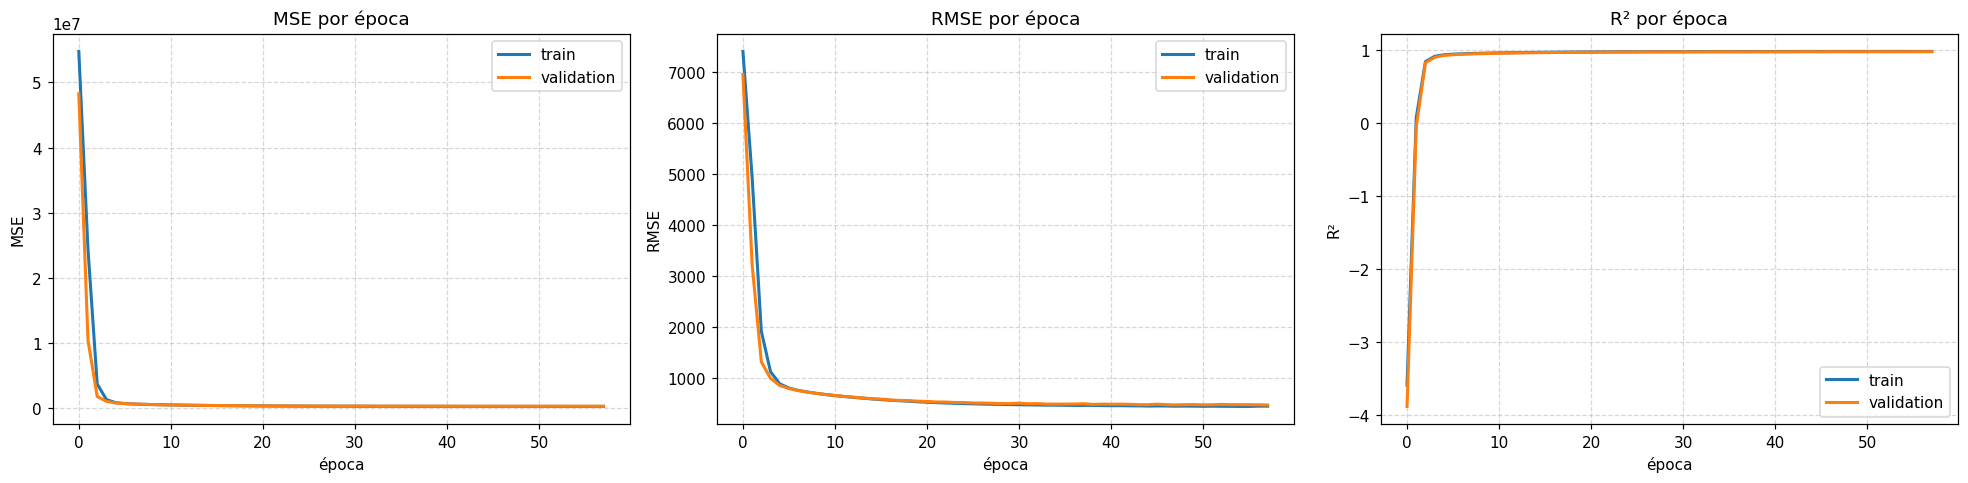

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# MSE por época
axes[0].plot(loss_hist, label="train", lw=2)
axes[0].plot(val_loss_hist, label="validación", lw=2)
axes[0].set_title("MSE por época"); axes[0].set_xlabel("época"); axes[0].set_ylabel("MSE")
axes[0].legend(); axes[0].grid(True, ls="--", alpha=0.5)

# RMSE por época
axes[1].plot([l**0.5 for l in loss_hist], label="train", lw=2)
axes[1].plot([l**0.5 for l in val_loss_hist], label="validación", lw=2)
axes[1].set_title("RMSE por época"); axes[1].set_xlabel("época"); axes[1].set_ylabel("RMSE")
axes[1].legend(); axes[1].grid(True, ls="--", alpha=0.5)

# R² por época
axes[2].plot(r2_train_hist, label="train", lw=2)
axes[2].plot(r2_val_hist, label="validación", lw=2)
axes[2].set_title("R² por época"); axes[2].set_xlabel("época"); axes[2].set_ylabel("R²")
axes[2].legend(); axes[2].grid(True, ls="--", alpha=0.5)

plt.tight_layout(); plt.show()

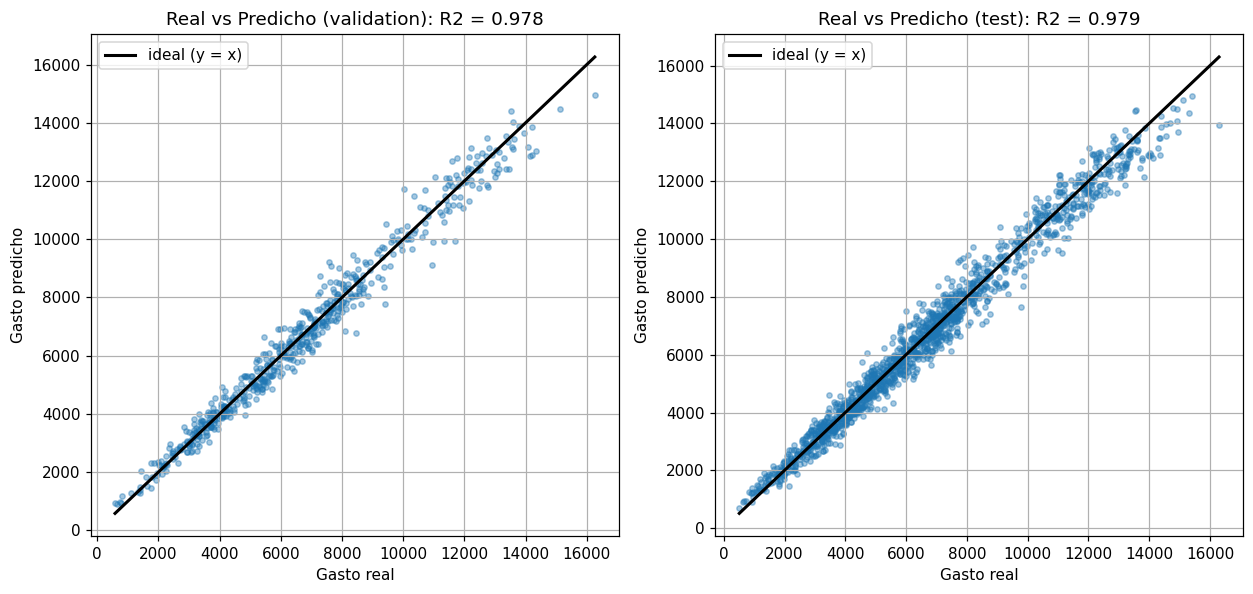

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.5))
for ax, (yt, yp, r2_i, titulo) in zip(axes, [
    (y_true_val, y_pred_val, r2_val, "validación"),
    (y_true_np, y_pred_np, r2, "test"),
]):
    ax.scatter(yt, yp, s=12, alpha=0.4)
    m = float(min(yt.min(), yp.min()))
    M = float(max(yt.max(), yp.max()))
    ax.plot([m, M], [m, M], color="black", lw=2, label="ideal (y = x)")
    ax.set_xlabel("Gasto real"); ax.set_ylabel("Gasto predicho")
    ax.set_title(f"Real vs Predicho ({titulo}): R2 = {r2_i:.3f}")
    ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

Llegar a estos resultados fue un proceso de varios pasos:

1. Primer intento: como el objetivo apunta a clientes nuevos de 3-5 visitas, arranqué construyendo los features con solo 3-5 transacciones por cliente. El R² quedó bajo, porque con tan pocas compras la información es demasiado ruidosa y el modelo no lograba estimar bien el gasto de largo plazo.
2. Segundo intento: usar todo el historial de transacciones. Ahí el R² subió fuerte, señal de que los features tienen buena señal cuando se calculan sobre suficientes compras. Este quedó como el modelo principal.
3. Revisión de features: saqué `n_transacciones` del modelo. Como vale la cantidad de compras (entre 9 y 50 acá), el modelo se aprendía ese rango y quedaba sesgado a valores altos, así que fallaba con clientes de pocas visitas. En su lugar sumé el máximo, el mínimo y el desvío del gasto, que describen cómo compra el cliente sin depender del volumen de compras.
4. Búsqueda de hiperparámetros con Optuna: en vez de seguir probando a mano el learning rate y las épocas, optimicé con Optuna para obtener los mejores valores.
5. Control de overfitting: miré las curvas de train vs validación por época. Van casi pegadas y el R² de validación se estabiliza en lugar de empeorar, así que el modelo generaliza bien y no hizo falta agregar regularización.
6. Saque `n_productos` pues crece con las compras acumuladas al igual que `n_transacciones`.

Resultados: el modelo con el historial completo de transacciones supera el R² de 0.70 pedido por la consigna, y el RMSE en test queda chico frente al gasto promedio por cliente (~6.700). En el apéndice, al final, retomo el escenario de pocas visitas del primer intento para dejar documentado cuánto rinde el modelo en las condiciones reales de uso.

### 2d) Conclusiones finales (0.5 puntos)
Redactar de manera detallada las conclusiones finales y si se cumplió con el objetivo o no.

El objetivo del caso era estimar el gasto promedio por cliente a partir de sus datos y sus patrones de compra, para usarlo sobre clientes relativamente nuevos. Cumplí el objetivo:

- EDA y preparación: pasé de 182.721 transacciones a una tabla de 7.432 clientes, traté los nulos (descarté subcategorías), saqué duplicados y definí el encoding de cada variable según su tipo (ordinal, binaria u one-hot), cuidando el data leakage: ningún feature usa el promedio ni el total del monto (que son el target), solo el máximo, mínimo y desvío, que describen la forma del gasto sin filtrarlo.
- Modelo: un MLP de 3 capas ocultas con ReLU, entrenado con Adam y MSE, con el learning rate y las épocas elegidos por Optuna. Supera el R² de 0.70 pedido por la consigna tanto en validación como en test.

En cuanto al negocio, el RMSE en test, reportado arriba, queda muy por debajo del gasto promedio por cliente de ~6.700, lo que hace al modelo útil para estimar cuánto va a gastar un cliente.

Como mejoras a futuro se podrían sumar más features de comportamiento, probar regularización como dropout o arquitecturas más grandes, y reentrenar con más clientes a medida que la tienda acumule datos.

## Apéndice: prueba de robustez con pocas transacciones (3-5)

Como análisis complementario, evalúo un escenario más restrictivo en el que las características de cada cliente se calculan usando únicamente entre 3 y 5 transacciones. Este experimento no forma parte del entrenamiento principal solicitado, sino que busca aproximar el comportamiento del modelo cuando existe poca información histórica.

In [71]:
# Reconstruyo train y test submuestreando 3-5 transacciones por cliente (mismos features, mismo split)
train_nuevo = construir_clientes(ids_train, seed=42, k_max=(3, 5))
test_nuevo = construir_clientes(ids_test, seed=123, k_max=(3, 5))

In [72]:
print("train_nuevo:", train_nuevo.shape)
train_nuevo.head()

train_nuevo: (5945, 32)


,User_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,n_categorias,categoria_fav,gasto_max,gasto_min,gasto_std,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20,gasto_promedio
0,1081994,26-35,M,0,B,1,4,19,21830,525,8492.677024,0.0,0.000000,0.000000,0.0,0.2,0.0,0.0,0.200000,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,8371.500000
1,1024167,36-45,M,1,A,1,4,18,25460,1011,9888.808070,0.0,0.200000,0.000000,0.0,0.0,0.2,0.0,0.000000,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.0,0.0,12081.674419
2,1079723,46-50,F,1,C,2,4,5,24070,79,9505.884885,0.0,0.000000,0.000000,0.0,0.4,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.2,0.2,0.0,0.0,0.0,2855.142857
3,1003912,0-17,M,0,A,2,5,1,5618,240,1996.298715,0.2,0.200000,0.200000,0.2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,3371.454545
4,1038453,46-50,M,1,B,5+,3,2,4797,527,1888.161716,0.0,0.333333,0.333333,0.0,0.0,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7416.040816


In [73]:
print("test_nuevo:", test_nuevo.shape)
test_nuevo.head()

test_nuevo: (1487, 32)


,User_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,n_categorias,categoria_fav,gasto_max,gasto_min,gasto_std,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20,gasto_promedio
0,1042228,36-45,M,0,B,1,5,2,12258,96,4550.433694,0.0,0.2,0.00,0.2,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.20,0.0,0.0,0.0,0.0,2661.437500
1,1070537,26-35,M,0,B,1,3,17,2936,305,1076.207316,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.25,0.5,0.0,0.0,0.0,3697.727273
2,1049628,18-25,M,0,A,2,5,3,11262,265,4212.843477,0.0,0.0,0.20,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.2,0.20,0.2,0.0,0.0,0.0,4941.076923
3,1044346,51-55,F,1,C,2,5,3,29870,2817,9416.410131,0.0,0.0,0.20,0.0,0.0,0.2,0.2,0.0,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.00,0.2,0.0,0.0,0.0,9066.684211
4,1054075,55+,F,1,C,5+,5,6,25790,1047,8238.428136,0.0,0.0,0.00,0.0,0.0,0.2,0.2,0.0,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.00,0.2,0.0,0.2,0.0,8022.128205


In [74]:
# Mismo encoding que el modelo principal (mappings fijos + one-hot ya ajustado)
train_nuevo = aplicar_mappings(train_nuevo)
test_nuevo = aplicar_mappings(test_nuevo)
train_nuevo = aplicar_ohe(train_nuevo)
test_nuevo = aplicar_ohe(test_nuevo)

In [75]:
y_train_n = train_nuevo["gasto_promedio"].values
X_train_n = train_nuevo.drop(columns=["User_ID", "gasto_promedio"])
y_test_n = test_nuevo["gasto_promedio"].values
X_test_n = test_nuevo.drop(columns=["User_ID", "gasto_promedio"])[X_train_n.columns]

In [76]:
# Separo validación antes de ajustar el scaler, igual que en el modelo principal (evitar leakage)
X_fit_n, X_val_n, y_fit_n, y_val_n = train_test_split(X_train_n, y_train_n, test_size=0.1, random_state=0)

In [77]:
# Escalo con el mismo criterio que el modelo principal
cont_n = [c for c in X_fit_n.columns
          if c not in ("Gender", "Marital_Status") and not c.startswith("catfav_")]
scaler_n = StandardScaler().fit(X_fit_n[cont_n])
X_fit_n = X_fit_n.copy(); X_val_n = X_val_n.copy(); X_test_n = X_test_n.copy()
X_fit_n[cont_n]  = scaler_n.transform(X_fit_n[cont_n])
X_val_n[cont_n]  = scaler_n.transform(X_val_n[cont_n])
X_test_n[cont_n] = scaler_n.transform(X_test_n[cont_n])

In [78]:
print(X_fit_n.shape, y_fit_n.shape)
print(X_val_n.shape, y_val_n.shape)
print(X_test_n.shape, y_test_n.shape)

(5350, 49) (5350,)
(595, 49) (595,)
(1487, 49) (1487,)


In [79]:
X_fit_n.head()

,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,n_categorias,gasto_max,gasto_min,gasto_std,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20,catfav_1,catfav_2,catfav_3,catfav_4,catfav_5,catfav_6,catfav_7,catfav_8,catfav_9,catfav_10,catfav_11,catfav_12,catfav_13,catfav_14,catfav_15,catfav_16,catfav_17,catfav_18,catfav_19,catfav_20
2374,1.498272,0,1,-1.385072,1.660715,0.504283,0.886954,-0.459014,1.018190,2.420305,-0.270804,-0.623377,1.624155,-0.493175,-0.335878,-0.346285,-0.417749,-0.397079,-0.592649,-0.469909,-0.502199,-0.350124,-0.347735,-0.432151,-0.557157,1.127633,-0.356032,-0.346299,2.049578,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1262,0.929859,0,1,-0.144674,1.660715,-0.666687,0.697277,0.367705,0.747148,-0.342954,-0.270804,1.044600,-0.470241,-0.493175,-0.335878,-0.346285,-0.417749,-0.397079,-0.592649,-0.469909,-0.502199,-0.350124,-0.347735,-0.432151,1.233752,-0.585268,-0.356032,-0.346299,4.490095,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1431,0.361447,1,1,-0.144674,1.660715,1.675254,-0.205587,0.325289,-0.318222,-0.342954,-0.270804,-0.623377,-0.470241,-0.493175,-0.335878,-0.346285,1.468955,1.614957,0.734224,1.151162,-0.502199,-0.350124,1.793304,-0.432151,-0.557157,-0.585268,-0.356032,-0.346299,-0.390939,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3416,-1.912204,1,0,1.095723,-1.144724,-0.666687,-0.334902,-0.450766,-0.110110,-0.342954,-0.270804,-0.623377,-0.470241,-0.493175,-0.335878,-0.346285,-0.417749,-0.397079,2.061096,-0.469909,2.688888,-0.350124,-0.347735,-0.432151,-0.557157,0.785053,-0.356032,-0.346299,-0.390939,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4129,-0.206966,1,0,-0.144674,-0.443364,0.504283,-1.351795,-0.506928,-1.271058,-0.342954,2.701606,-0.623377,1.205275,-0.493175,-0.335878,-0.346285,-0.417749,-0.397079,2.061096,-0.469909,-0.502199,-0.350124,-0.347735,-0.432151,0.875571,-0.585268,-0.356032,-0.346299,-0.390939,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [80]:
X_val_n.head()

,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,n_categorias,gasto_max,gasto_min,gasto_std,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20,catfav_1,catfav_2,catfav_3,catfav_4,catfav_5,catfav_6,catfav_7,catfav_8,catfav_9,catfav_10,catfav_11,catfav_12,catfav_13,catfav_14,catfav_15,catfav_16,catfav_17,catfav_18,catfav_19,catfav_20
134,0.361447,0,1,-0.144674,-1.144724,-0.666687,-1.539241,-0.464119,-1.466029,-0.342954,-0.270804,-0.623377,1.624155,-0.493175,-0.335878,-0.346285,-0.417749,-0.397079,-0.592649,-0.469909,-0.502199,-0.350124,-0.347735,4.090851,-0.557157,1.127633,-0.356032,-0.346299,-0.390939,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1364,0.361447,0,1,-0.144674,0.257996,-0.666687,0.708434,-0.366327,1.182231,-0.342954,-0.270804,1.600593,-0.470241,-0.493175,-0.335878,-0.346285,-0.417749,-0.397079,-0.592649,-0.469909,-0.502199,-0.350124,-0.347735,-0.432151,1.830722,1.698600,-0.356032,-0.346299,-0.390939,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
555,-0.775378,1,0,1.095723,-0.443364,-0.666687,1.727113,-0.333337,1.997710,-0.342954,-0.270804,1.600593,2.322286,-0.493175,-0.335878,-0.346285,-0.417749,2.956314,-0.592649,-0.469909,-0.502199,-0.350124,-0.347735,-0.432151,-0.557157,-0.585268,-0.356032,-0.346299,-0.390939,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4139,-0.775378,1,0,1.095723,-1.144724,0.504283,1.329906,1.116269,0.847244,-0.342954,-0.270804,1.044600,-0.470241,-0.493175,-0.335878,-0.346285,-0.417749,-0.397079,-0.592649,-0.469909,1.492231,-0.350124,-0.347735,-0.432151,-0.557157,-0.585268,2.358091,-0.346299,2.049578,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2857,-0.775378,1,0,1.095723,0.959355,0.504283,0.604670,0.820143,0.295950,2.420305,-0.270804,-0.623377,-0.470241,-0.493175,2.467471,-0.346285,-0.417749,-0.397079,-0.592649,-0.469909,1.492231,-0.350124,-0.347735,-0.432151,-0.557157,-0.585268,2.358091,-0.346299,-0.390939,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [81]:
X_test_n.head()

,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,n_categorias,gasto_max,gasto_min,gasto_std,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20,catfav_1,catfav_2,catfav_3,catfav_4,catfav_5,catfav_6,catfav_7,catfav_8,catfav_9,catfav_10,catfav_11,catfav_12,catfav_13,catfav_14,catfav_15,catfav_16,catfav_17,catfav_18,catfav_19,catfav_20
0,-0.206966,1,0,-0.144674,-1.144724,1.675254,-0.237943,-0.520281,-0.201662,-0.342954,2.701606,-0.623377,1.205275,-0.493175,1.906801,-0.346285,-0.417749,-0.397079,-0.592649,-0.469909,-0.502199,-0.350124,-0.347735,1.377050,0.875571,-0.585268,-0.356032,-0.346299,-0.390939,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,-0.775378,1,0,-0.144674,-1.144724,-0.666687,-1.278044,-0.438199,-1.198380,-0.342954,-0.270804,1.044600,-0.470241,-0.493175,-0.335878,-0.346285,-0.417749,-0.397079,-0.592649,-0.469909,-0.502199,-0.350124,-0.347735,-0.432151,1.233752,2.840533,-0.356032,-0.346299,-0.390939,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,-1.343791,1,0,1.095723,-0.443364,1.675254,-0.349072,-0.453908,-0.298513,-0.342954,-0.270804,0.711005,-0.470241,-0.493175,-0.335878,-0.346285,-0.417749,1.614957,-0.592649,-0.469909,-0.502199,-0.350124,-0.347735,1.377050,0.875571,0.785053,-0.356032,-0.346299,-0.390939,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0.929859,0,1,-1.385072,-0.443364,1.675254,1.727113,0.548366,1.194335,-0.342954,-0.270804,0.711005,-0.470241,-0.493175,1.906801,1.803348,-0.417749,-0.397079,-0.592649,-0.469909,1.093345,-0.350124,-0.347735,-0.432151,-0.557157,0.785053,-0.356032,-0.346299,-0.390939,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1.498272,0,1,-1.385072,1.660715,1.675254,1.271887,-0.146785,0.856384,-0.342954,-0.270804,-0.623377,-0.470241,-0.493175,1.906801,1.803348,-0.417749,-0.397079,-0.592649,1.151162,-0.502199,-0.350124,-0.347735,-0.432151,-0.557157,0.785053,-0.356032,1.777953,-0.390939,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [82]:
# Entreno la misma arquitectura con el mismo lr y epocas sobre el escenario de 3-5 visitas.
X_fit_nt, y_fit_nt = a_tensor(X_fit_n, y_fit_n)
X_val_nt, y_val_nt = a_tensor(X_val_n, y_val_n)
X_test_nt, y_test_nt = a_tensor(X_test_n, y_test_n)
dl_n = DataLoader(TensorDataset(X_fit_nt, y_fit_nt), batch_size=batch_size, shuffle=True)

torch.manual_seed(0)
model_nuevo = construir_mlp(X_fit_nt.shape[1])
_ = entrenar(model_nuevo, dl_n, lr, epochs,
             datos_val=(X_val_nt, y_val_nt),
             datos_fit=(X_fit_nt, y_fit_nt),
             verbose=True)

época  10 | RMSE train 2107 | RMSE val 2204 | R² val 0.508


época  20 | RMSE train 2062 | RMSE val 2197 | R² val 0.511


época  30 | RMSE train 2046 | RMSE val 2187 | R² val 0.516


época  40 | RMSE train 2018 | RMSE val 2194 | R² val 0.513


época  50 | RMSE train 2006 | RMSE val 2193 | R² val 0.513


In [83]:
model_nuevo.eval()
with torch.no_grad():
    pred_n = model_nuevo(X_test_nt)
    rmse_n = mse_loss(pred_n, y_test_nt).item() ** 0.5
    r2_n = r2_score(y_test_nt.cpu().numpy().ravel(), pred_n.cpu().numpy().ravel())

print(f"Historial completo de transacciones -> RMSE {rmse:.0f} | R² {r2:.3f}")
print(f"Clientes 3-5 visitas -> RMSE {rmse_n:.0f} | R² {r2_n:.3f}")

Historial completo de transacciones -> RMSE 471 | R² 0.979
Clientes 3-5 visitas -> RMSE 2241 | R² 0.523


Resultados:

- Con el historial completo el modelo explica casi toda la varianza del gasto promedio. Con 3-5 compras el R² cae bastante, porque con tan pocas compras los features son ruidosos y no describen bien al cliente.
- Por lo tanto, el resultado no invalida el modelo principal, sino que evidencia la limitación natural de predecir cuando todavía se dispone de poca información. Para el negocio, con 3-5 visitas conviene informar un rango de gasto estimado más que un número fijo, y la estimación mejora a medida que el cliente acumula compras.